In [13]:
import os
print("Répertoire actuel :", os.getcwd())
print("Contenu du répertoire :", os.listdir())
# Vérifie si le dossier 'data' existe
if os.path.exists('data'):
    print("Contenu de 'data' :", os.listdir('data'))
else:
    print("Le dossier 'data' n'existe pas ici.")

Répertoire actuel : c:\Users\Sirine\Documents\projet covid\notebooks
Contenu du répertoire : ['eda_covid19.ipynb']
Le dossier 'data' n'existe pas ici.


TACHE 1 


In [35]:
# ============================================================
# IMPORTS ET CHARGEMENT CORRIGÉ (avec recherche du fichier)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats
from scipy.stats import mannwhitneyu, shapiro, chi2_contingency
import warnings
import os
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid', palette='muted')

COLOR_POS = '#E74C3C'
COLOR_NEG = '#2ECC71'
COLOR_MAIN = '#2C3E50'

# Recherche automatique du fichier
filename = 'CoronaVirusData (1).csv'
possible_paths = [
    filename,                     # même dossier que notebook
    os.path.join('..', filename), # dossier parent
    os.path.join('..', 'data', filename), # dossier parent/data
    os.path.join('data', filename)        # dossier data
]

df = None
for path in possible_paths:
    if os.path.exists(path):
        df = pd.read_csv(path, sep=';', encoding='utf-8', engine='python')
        print(f"✅ Fichier trouvé : {path}")
        break

if df is None:
    raise FileNotFoundError(f"Fichier {filename} introuvable dans les chemins : {possible_paths}")

# Nettoyage des noms de colonnes
df.columns = (df.columns
              .str.replace('\n', ' ', regex=False)
              .str.replace('\r', ' ', regex=False)
              .str.strip()
              .str.replace(r'\s+', ' ', regex=True))

print(f"✅ Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes")

# Trouver la colonne cible
possible_targets = [col for col in df.columns if 'SARS-Cov-2 exam result' in col]
if possible_targets:
    TARGET = possible_targets[0]
else:
    raise KeyError("Impossible de trouver la colonne cible contenant 'SARS-Cov-2 exam result'")
print(f"✅ Variable cible identifiée : {TARGET}")

✅ Fichier trouvé : ..\data\CoronaVirusData (1).csv
✅ Dataset chargé : 5644 lignes × 111 colonnes
✅ Variable cible identifiée : SARS-Cov-2 exam result


In [36]:
# ============================================================
# TÂCHE 1 : ANALYSE DE FORME
# ============================================================

print('=' * 60)
print('  📐 Q1 — DIMENSIONS DU DATASET')
print('=' * 60)
lignes, colonnes = df.shape
print(f'  ➤ {lignes} lignes  ×  {colonnes} colonnes\n')

print('=' * 60)
print('  🔤 Q2 — TYPES DE VARIABLES')
print('=' * 60)
print(df.dtypes.value_counts().to_string())

print('\n' + '=' * 60)
print('  📊 Q3 — VARIABLES QUALITATIVES vs QUANTITATIVES')
print('=' * 60)
quanti = df.select_dtypes(include=[np.number]).columns.tolist()
quali  = df.select_dtypes(exclude=[np.number]).columns.tolist()
print(f'  ➤ Quantitatives : {len(quanti)} variables')
print(f'  ➤ Qualitatives  : {len(quali)} variables')

print('\n' + '=' * 60)
print('  🎯 Q4 — VARIABLE CIBLE')
print('=' * 60)
print(f'  ➤ Nom     : "{TARGET}"')
print(f'  ➤ Modalités : {df[TARGET].unique()}')

print('\n' + '=' * 60)
print('  📈 Q5 — DISTRIBUTION DE LA CIBLE')
print('=' * 60)
dist     = df[TARGET].value_counts()
dist_pct = df[TARGET].value_counts(normalize=True) * 100
for val in dist.index:
    bar = '█' * int(dist_pct[val] / 2)
    print(f'  {val:12s}: {dist[val]:5d} pts ({dist_pct[val]:.1f}%)  {bar}')

ratio = dist['negative'] / dist['positive']
print(f'\n  ⚠️  Ratio déséquilibre  →  {ratio:.1f} négatifs pour 1 positif')
print(f'  ⚠️  Classe minoritaire  →  seulement {dist_pct["positive"]:.1f}% de positifs')

  📐 Q1 — DIMENSIONS DU DATASET
  ➤ 5644 lignes  ×  111 colonnes

  🔤 Q2 — TYPES DE VARIABLES
float64    70
str        37
int64       4

  📊 Q3 — VARIABLES QUALITATIVES vs QUANTITATIVES
  ➤ Quantitatives : 74 variables
  ➤ Qualitatives  : 37 variables

  🎯 Q4 — VARIABLE CIBLE
  ➤ Nom     : "SARS-Cov-2 exam result"
  ➤ Modalités : <StringArray>
['negative', 'positive']
Length: 2, dtype: str

  📈 Q5 — DISTRIBUTION DE LA CIBLE
  negative    :  5086 pts (90.1%)  █████████████████████████████████████████████
  positive    :   558 pts (9.9%)  ████

  ⚠️  Ratio déséquilibre  →  9.1 négatifs pour 1 positif
  ⚠️  Classe minoritaire  →  seulement 9.9% de positifs


Visualisation Tâche 1


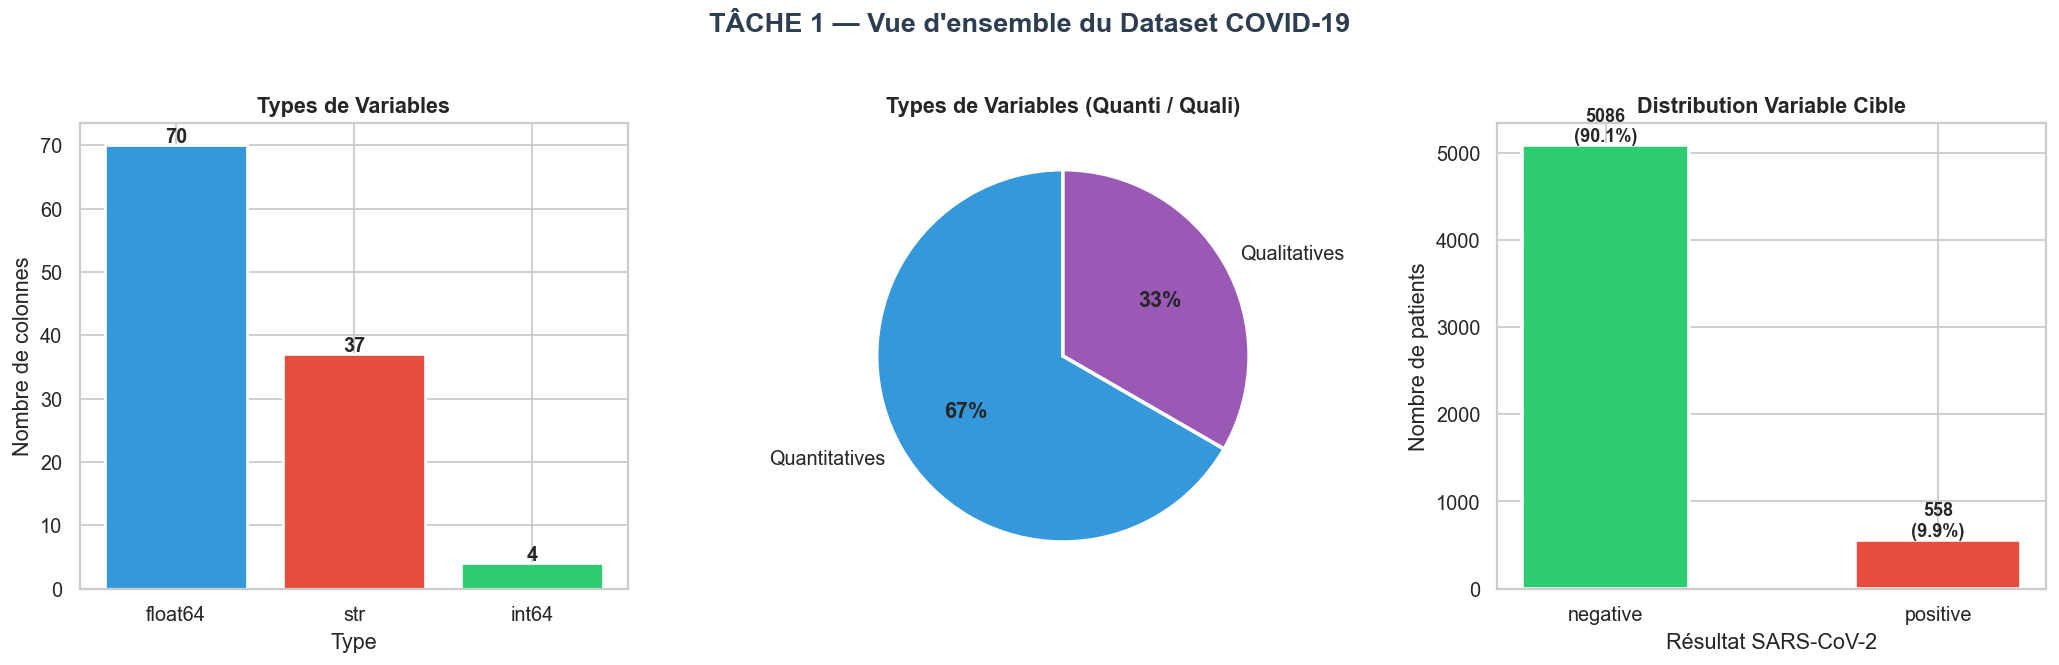

✅ Graphique sauvegardé : tache1_forme.png


In [37]:
# ---- Visualisation Tâche 1 : Dashboard de présentation ----
# Vérification que les variables existent
if 'quanti' not in locals() or 'quali' not in locals():
    quanti = df.select_dtypes(include=[np.number]).columns.tolist()
    quali  = df.select_dtypes(exclude=[np.number]).columns.tolist()
if 'dist' not in locals() or 'dist_pct' not in locals():
    dist = df[TARGET].value_counts()
    dist_pct = df[TARGET].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('TÂCHE 1 — Vue d\'ensemble du Dataset COVID-19', fontsize=15,
             fontweight='bold', color=COLOR_MAIN, y=1.02)

# --- Plot 1 : Répartition des types ---
type_counts = df.dtypes.value_counts()
colors1 = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12']
axes[0].bar(type_counts.index.astype(str), type_counts.values,
            color=colors1[:len(type_counts)], edgecolor='white', linewidth=1.5)
axes[0].set_title('Types de Variables', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Type')
axes[0].set_ylabel('Nombre de colonnes')
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold', fontsize=11)

# --- Plot 2 : Quanti vs Quali ---
labels2  = ['Quantitatives', 'Qualitatives']
values2  = [len(quanti), len(quali)]
colors2  = ['#3498DB', '#9B59B6']
wedges, texts, autotexts = axes[1].pie(
    values2, labels=labels2, autopct='%1.0f%%',
    colors=colors2, startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2})
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(12)
axes[1].set_title('Types de Variables (Quanti / Quali)', fontweight='bold', fontsize=12)

# --- Plot 3 : Distribution cible ---
colors3 = [COLOR_NEG, COLOR_POS]
bars = axes[2].bar(dist.index, dist.values, color=colors3, edgecolor='white',
                   linewidth=2, width=0.5)
axes[2].set_title('Distribution Variable Cible', fontweight='bold', fontsize=12)
axes[2].set_ylabel('Nombre de patients')
axes[2].set_xlabel('Résultat SARS-CoV-2')
for bar, val, pct in zip(bars, dist.values, dist_pct.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                 f'{val}\n({pct:.1f}%)', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('tache1_forme.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Graphique sauvegardé : tache1_forme.png')

TÂCHE 2 : VALEURS MANQUANTES

  🔍 ANALYSE DES VALEURS MANQUANTES

📊 NaN global : 88.1% du dataset
📊 Variables sans NaN : 6
📊 Variables avec >90% NaN : 72

  📋 TOP 15 COLONNES AVEC LE PLUS DE NaN
Mycoplasma pneumoniae                   100.000000
Prothrombin time (PT), Activity         100.000000
D-Dimer                                 100.000000
Urine - Sugar                           100.000000
Partial thromboplastin time (PTT)       100.000000
Urine - Nitrite                          99.982282
Fio2 (venous blood gas analysis)         99.982282
Vitamin B12                              99.946846
Lipase dosage                            99.858257
Albumin                                  99.769667
Phosphor                                 99.645641
Arteiral Fio2                            99.645641
Ferritin                                 99.592488
Arterial Lactic Acid                     99.521616
Hb saturation (arterial blood gases)     99.521616


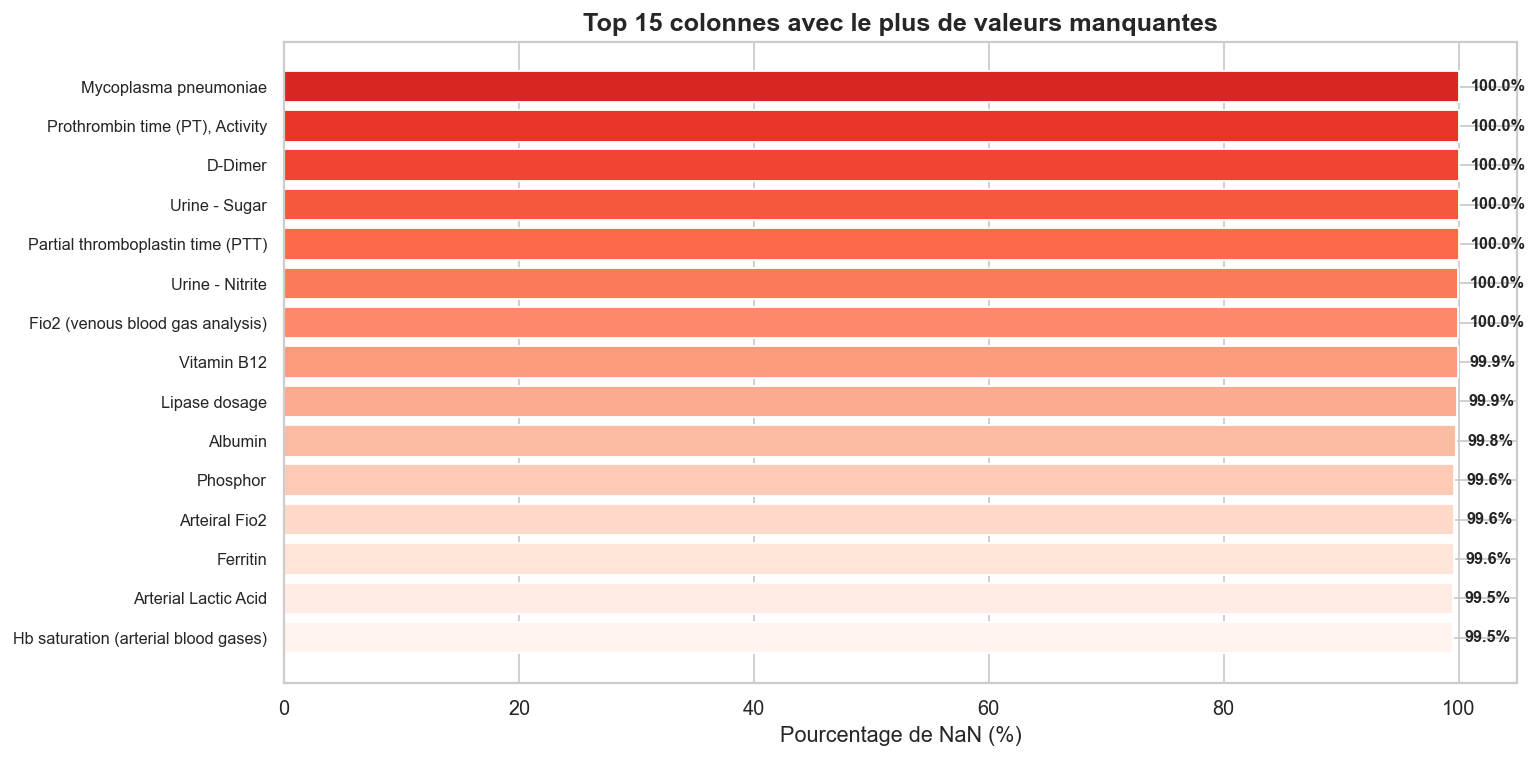


  🔬 DEUX GROUPES DE VARIABLES IDENTIFIÉS
  🦠 Tests viraux    : 17 variables
  🩸 Taux sanguins   : 17 variables
     → NaN moyen : 78.2%
     → NaN moyen : 91.5%

  📊 LIGNES EXPLOITABLES
  🦠 Tests viraux seuls    : 1956 lignes (34.7%)
  🩸 Taux sanguins seuls   : 620 lignes (11.0%)
  ⚠️  Les deux combinés     : 0 lignes (0.0%)

📊 Génération des heatmaps ciblées...


<Figure size 1820x1040 with 0 Axes>

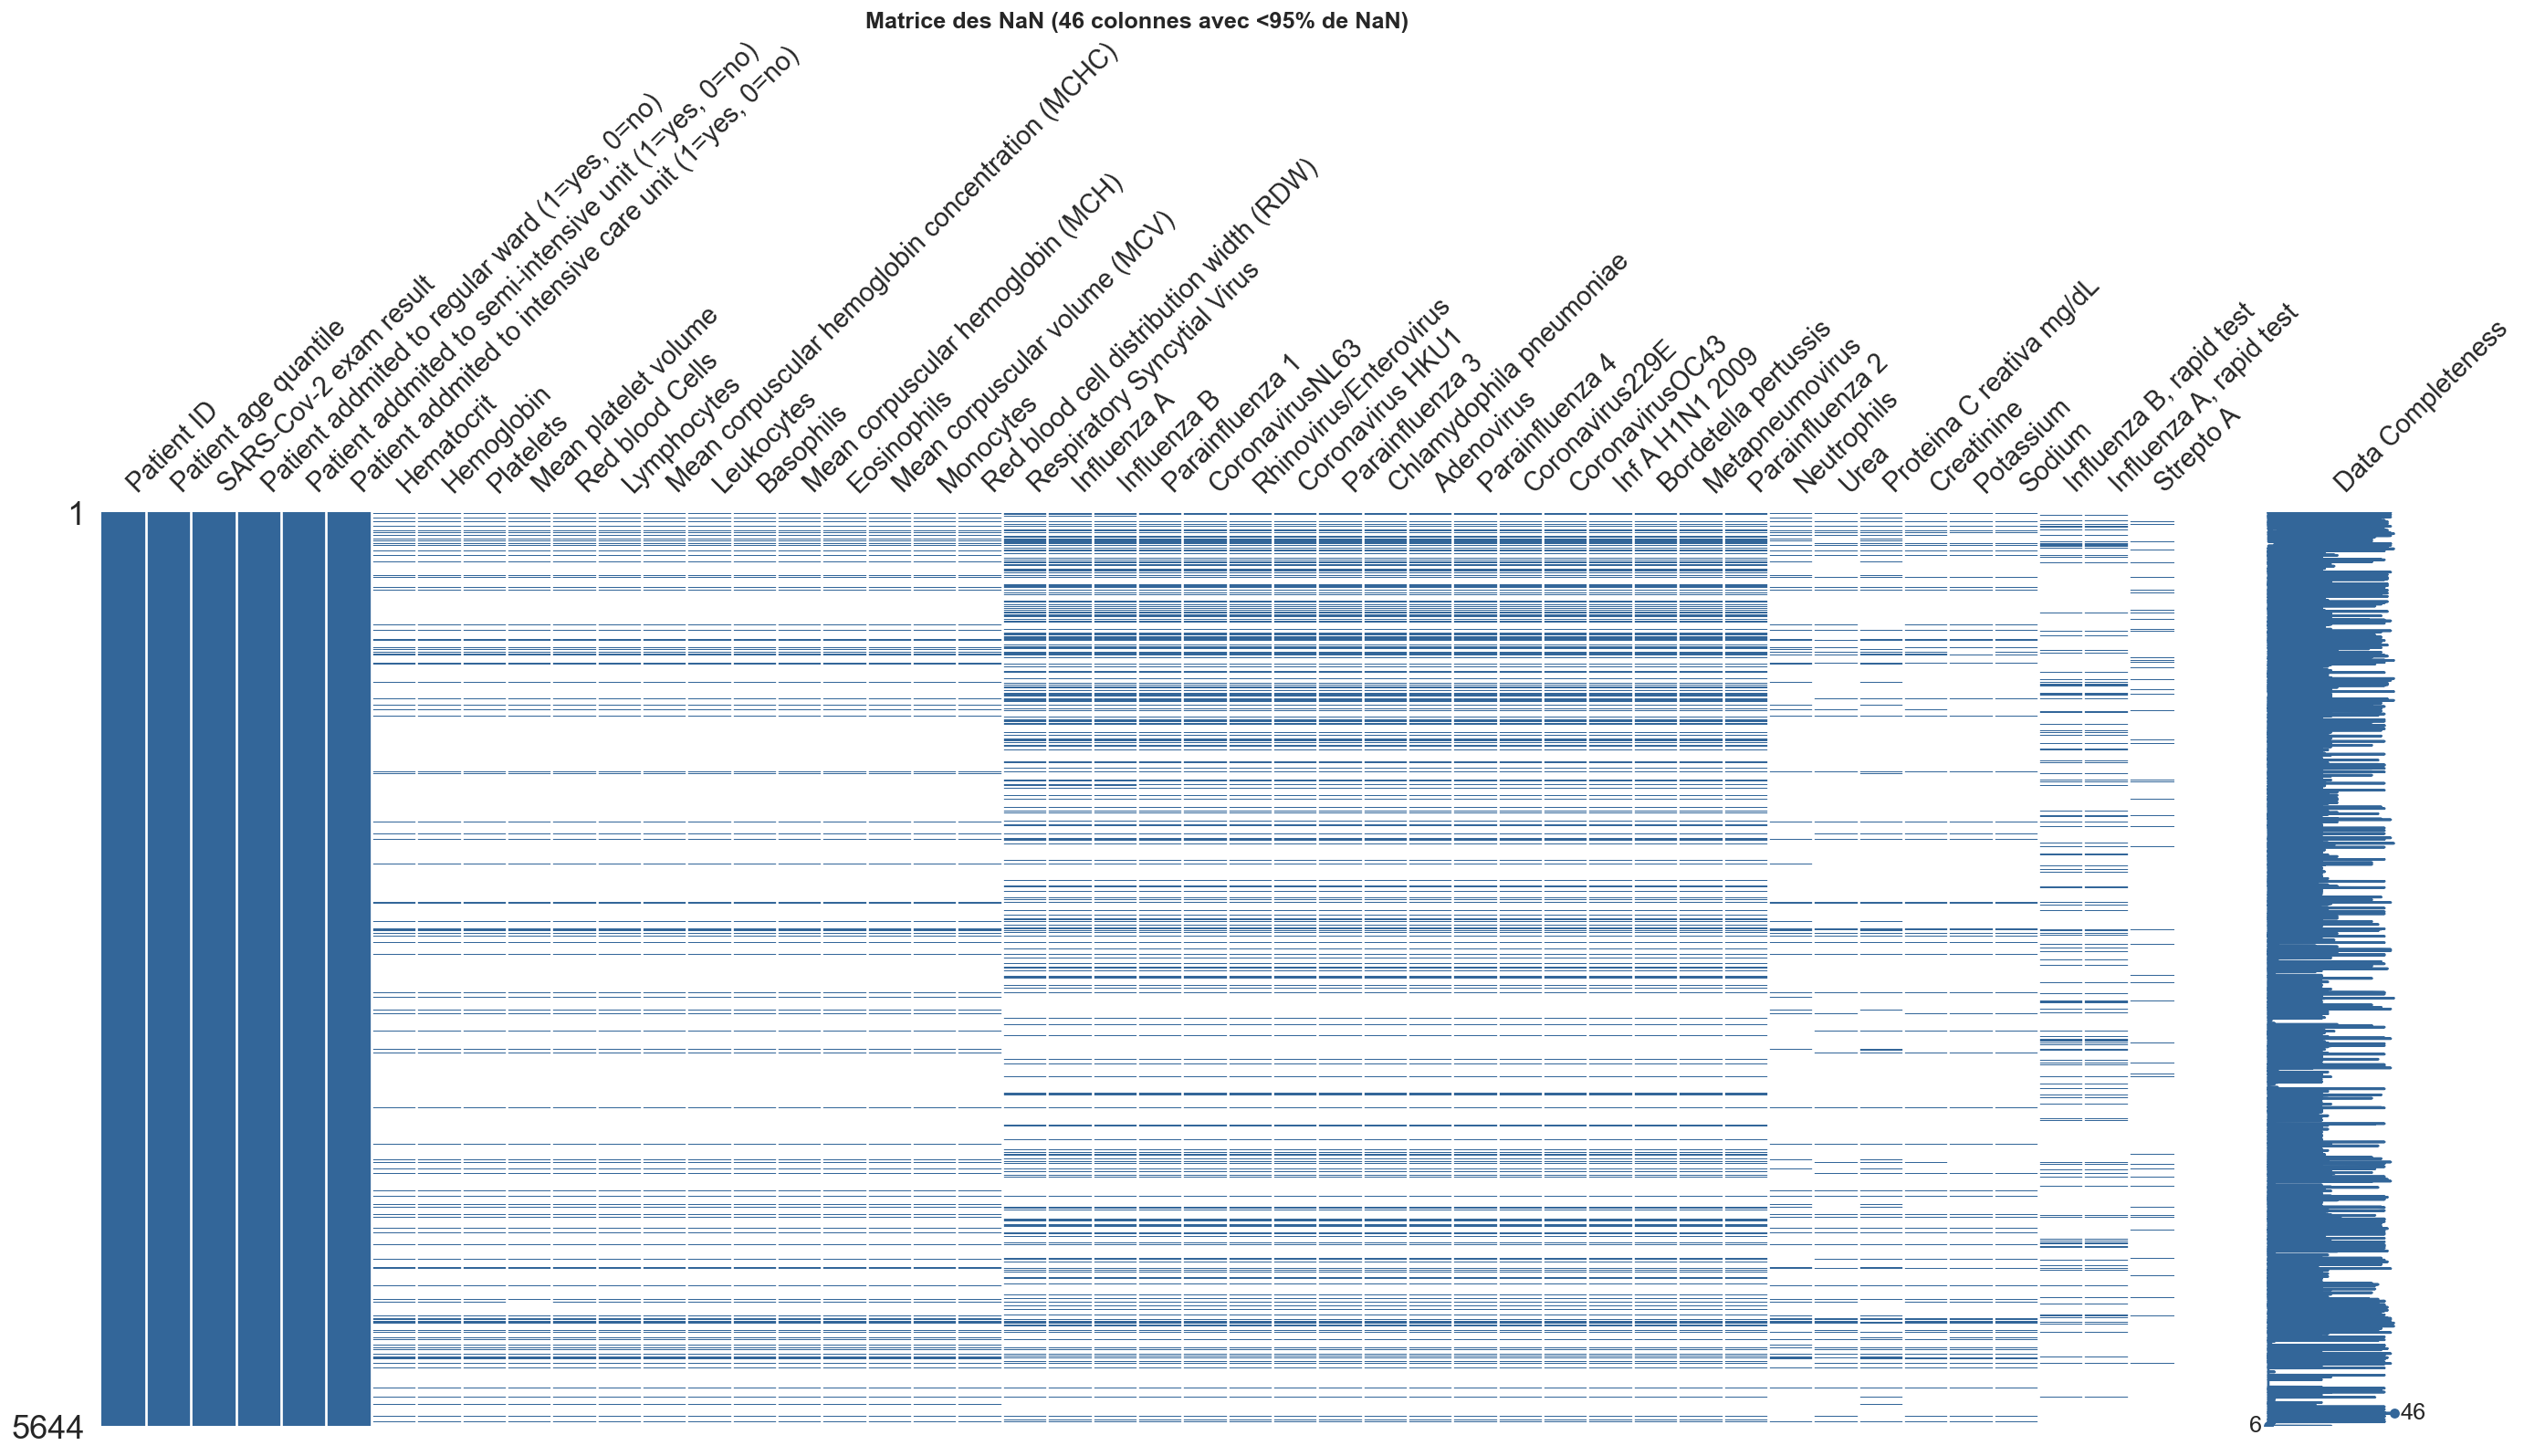

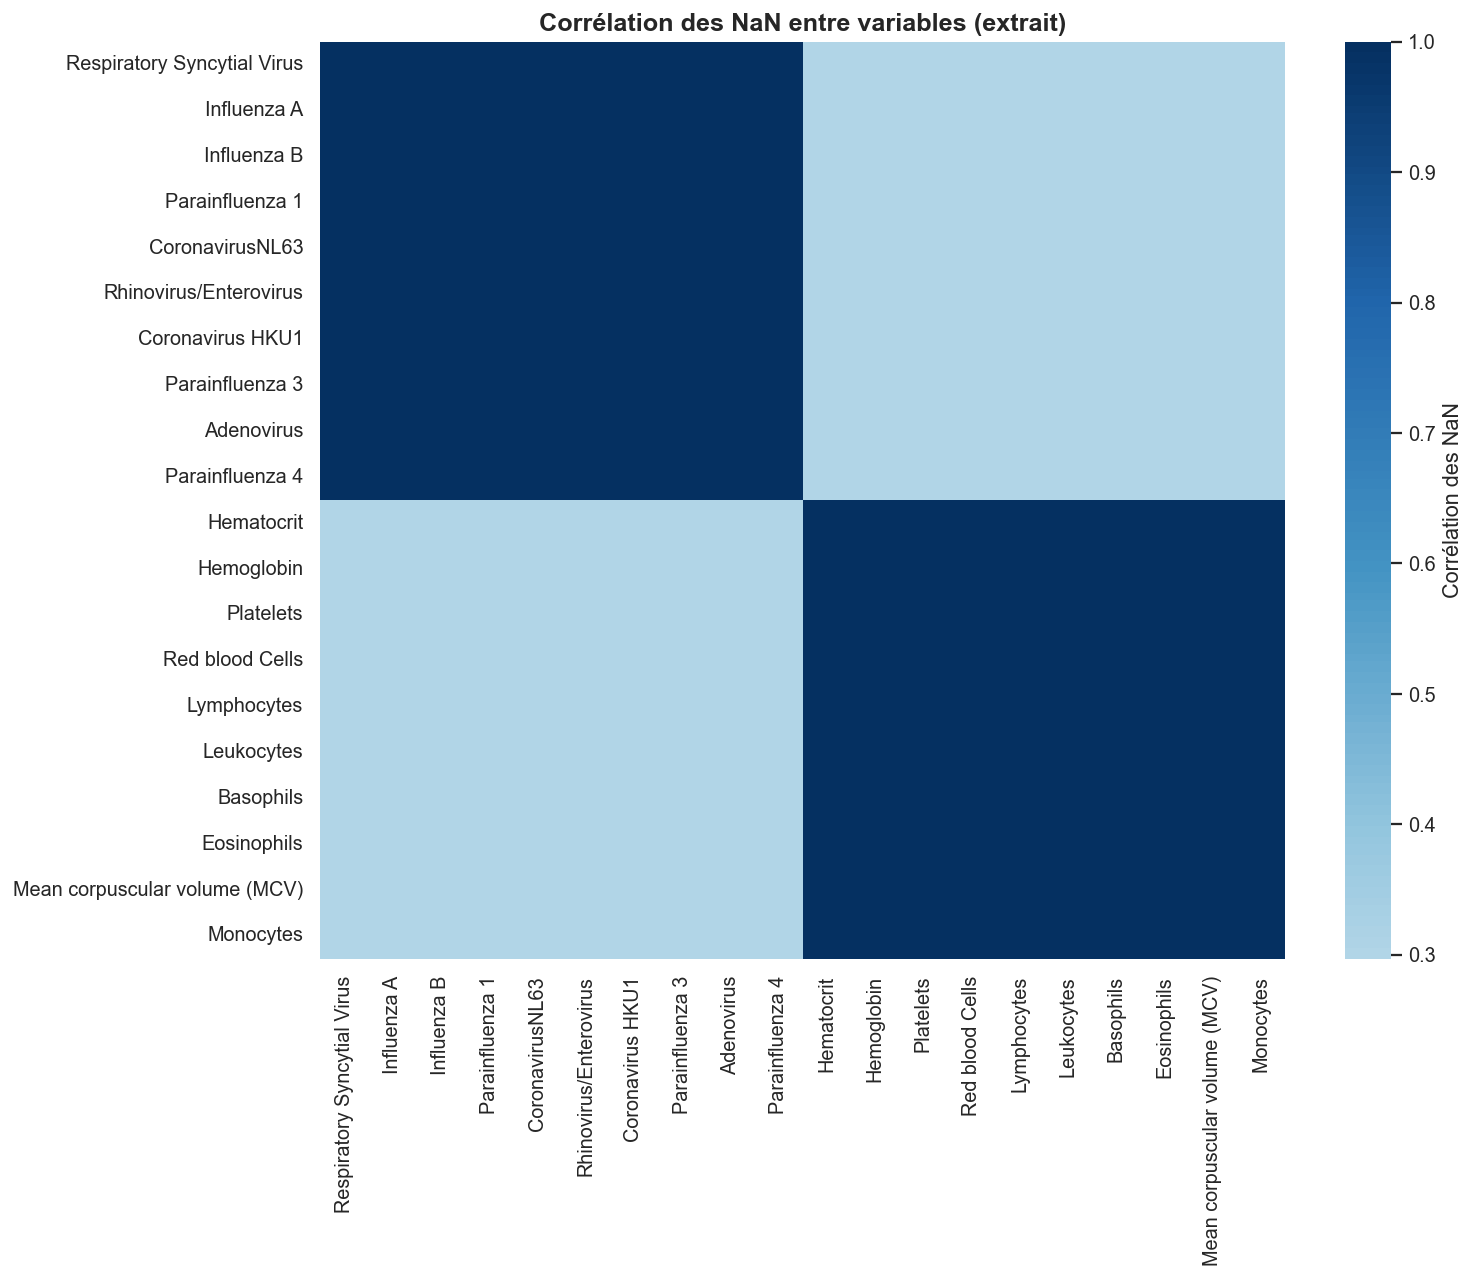


  💡 CONCLUSION ET STRATÉGIE RECOMMANDÉE

  📌 Les NaN ne sont PAS aléatoires (pattern par blocs)
  📌 Deux populations distinctes : tests viraux vs taux sanguins
  📌 Mécanisme probable : MAR (Missing At Random)

  ✅ STRATÉGIE :
     1. Analyser les deux groupes SÉPARÉMENT
     2. NE PAS imputer les tests viraux (binaires)
     3. Pour la modélisation : sous-ensembles cohérents
     4. Jamais combiner les deux groupes sans précaution

✅ Tâche 2 terminée - Graphiques sauvegardés :
   • tache2_top_nan.png
   • tache2_nan_matrix.png
   • tache2_nan_correlation.png


In [42]:
# ============================================================
# TÂCHE 2 : ANALYSE DES VALEURS MANQUANTES 
# ============================================================

print('=' * 60)
print('  🔍 ANALYSE DES VALEURS MANQUANTES')
print('=' * 60)

# 1. Statistiques globales
missing_pct = df.isnull().sum() / len(df) * 100
missing_pct = missing_pct.sort_values(ascending=False)

global_nan = df.isnull().sum().sum() / df.size * 100
print(f'\n📊 NaN global : {global_nan:.1f}% du dataset')
print(f'📊 Variables sans NaN : {(missing_pct == 0).sum()}')
print(f'📊 Variables avec >90% NaN : {(missing_pct > 90).sum()}')

# 2. Top 15 colonnes avec le plus de NaN
print('\n' + '=' * 60)
print('  📋 TOP 15 COLONNES AVEC LE PLUS DE NaN')
print('=' * 60)
print(missing_pct.head(15).to_string())

# 3. Visualisation : Barplot des 15 colonnes avec le plus de NaN
plt.figure(figsize=(12, 6))
colors = plt.cm.Reds_r(np.linspace(0.3, 1, 15))
bars = plt.barh(range(15), missing_pct.head(15).values, color=colors, edgecolor='white')
plt.yticks(range(15), missing_pct.head(15).index, fontsize=9)
plt.xlabel('Pourcentage de NaN (%)', fontsize=12)
plt.title('Top 15 colonnes avec le plus de valeurs manquantes', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
for i, (bar, val) in enumerate(zip(bars, missing_pct.head(15).values)):
    plt.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', 
             va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('tache2_top_nan.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. Identifier les deux groupes
viral_keywords = ['Virus', 'Influenza', 'Rhinovirus', 'Parainfluenza', 
                  'Coronavirus', 'Adenovirus', 'Metapneumovirus', 'Strepto']
blood_keywords = ['Leukocytes', 'Lymphocytes', 'Monocytes', 'Platelets', 
                  'Hematocrit', 'Hemoglobin', 'Red blood', 'Eosinophils', 
                  'Basophils', 'MCV', 'Neutrophils', 'CRP', 'Urea', 'Creatinine']

viral_cols = [col for col in df.columns if any(kw in col for kw in viral_keywords)]
blood_cols = [col for col in df.columns if any(kw in col for kw in blood_keywords)]

print('\n' + '=' * 60)
print('  🔬 DEUX GROUPES DE VARIABLES IDENTIFIÉS')
print('=' * 60)
print(f'  🦠 Tests viraux    : {len(viral_cols)} variables')
print(f'  🩸 Taux sanguins   : {len(blood_cols)} variables')

if viral_cols:
    nan_viral = df[viral_cols].isnull().mean().mean() * 100
    print(f'     → NaN moyen : {nan_viral:.1f}%')
if blood_cols:
    nan_blood = df[blood_cols].isnull().mean().mean() * 100
    print(f'     → NaN moyen : {nan_blood:.1f}%')

# 5. Lignes exploitables
print('\n' + '=' * 60)
print('  📊 LIGNES EXPLOITABLES')
print('=' * 60)

if viral_cols:
    rows_viral = df[viral_cols].dropna(how='all').shape[0]
    print(f'  🦠 Tests viraux seuls    : {rows_viral} lignes ({rows_viral/len(df)*100:.1f}%)')
if blood_cols:
    rows_blood = df[blood_cols].dropna(how='all').shape[0]
    print(f'  🩸 Taux sanguins seuls   : {rows_blood} lignes ({rows_blood/len(df)*100:.1f}%)')
if viral_cols and blood_cols:
    rows_both = df[viral_cols + blood_cols].dropna().shape[0]
    print(f'  ⚠️  Les deux combinés     : {rows_both} lignes ({rows_both/len(df)*100:.1f}%)')

# 6. Visualisation : Heatmap ciblée (uniquement les colonnes avec peu de NaN)
print('\n📊 Génération des heatmaps ciblées...')

# Ne garder que les colonnes avec <95% de NaN pour une heatmap lisible
cols_to_show = [col for col in df.columns if missing_pct[col] < 95]
df_heatmap = df[cols_to_show]

plt.figure(figsize=(14, 8))
msno.matrix(df_heatmap, labels=True, color=(0.2, 0.4, 0.6))
plt.title(f'Matrice des NaN ({len(cols_to_show)} colonnes avec <95% de NaN)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('tache2_nan_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# 7. Heatmap de corrélation des NaN (uniquement sur les groupes principaux)
if viral_cols and blood_cols:
    plt.figure(figsize=(12, 10))
    nan_corr = df[viral_cols[:10] + blood_cols[:10]].isnull().corr()
    sns.heatmap(nan_corr, cmap='RdBu', center=0, annot=False, 
                cbar_kws={'label': 'Corrélation des NaN'})
    plt.title('Corrélation des NaN entre variables (extrait)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('tache2_nan_correlation.png', dpi=150, bbox_inches='tight')
    plt.show()

# 8. Conclusion
print('\n' + '=' * 60)
print('  💡 CONCLUSION ET STRATÉGIE RECOMMANDÉE')
print('=' * 60)
print('''
  📌 Les NaN ne sont PAS aléatoires (pattern par blocs)
  📌 Deux populations distinctes : tests viraux vs taux sanguins
  📌 Mécanisme probable : MAR (Missing At Random)
  
  ✅ STRATÉGIE :
     1. Analyser les deux groupes SÉPARÉMENT
     2. NE PAS imputer les tests viraux (binaires)
     3. Pour la modélisation : sous-ensembles cohérents
     4. Jamais combiner les deux groupes sans précaution
''')

print('✅ Tâche 2 terminée - Graphiques sauvegardés :')
print('   • tache2_top_nan.png')
print('   • tache2_nan_matrix.png')
print('   • tache2_nan_correlation.png')

TÂCHE 3 : VARIABLE CIBLE 

  🎯 TÂCHE 3 — DÉSÉQUILIBRE DES CLASSES (CLASS IMBALANCE)

──────────────────────────────────────────────────────────────────────
  📊 QUESTION 1 — DISTRIBUTION EXACTE
──────────────────────────────────────────────────────────────────────

  ➤ Négatifs :  5086 patients  (90.1%)
  ➤ Positifs :   558 patients  (9.9%)

──────────────────────────────────────────────────────────────────────
  ⚖️  QUESTION 2 — RATIO D'IMBALANCE
──────────────────────────────────────────────────────────────────────

  ➤ Ratio négatifs/positifs : 9.11:1
  ➤ La classe minoritaire représente seulement 9.9% des données
  ➤ Déséquilibre CRITIQUE (>5:1) → risque élevé de modèle biaisé

──────────────────────────────────────────────────────────────────────
  📈 QUESTION 3 — VISUALISATION
──────────────────────────────────────────────────────────────────────


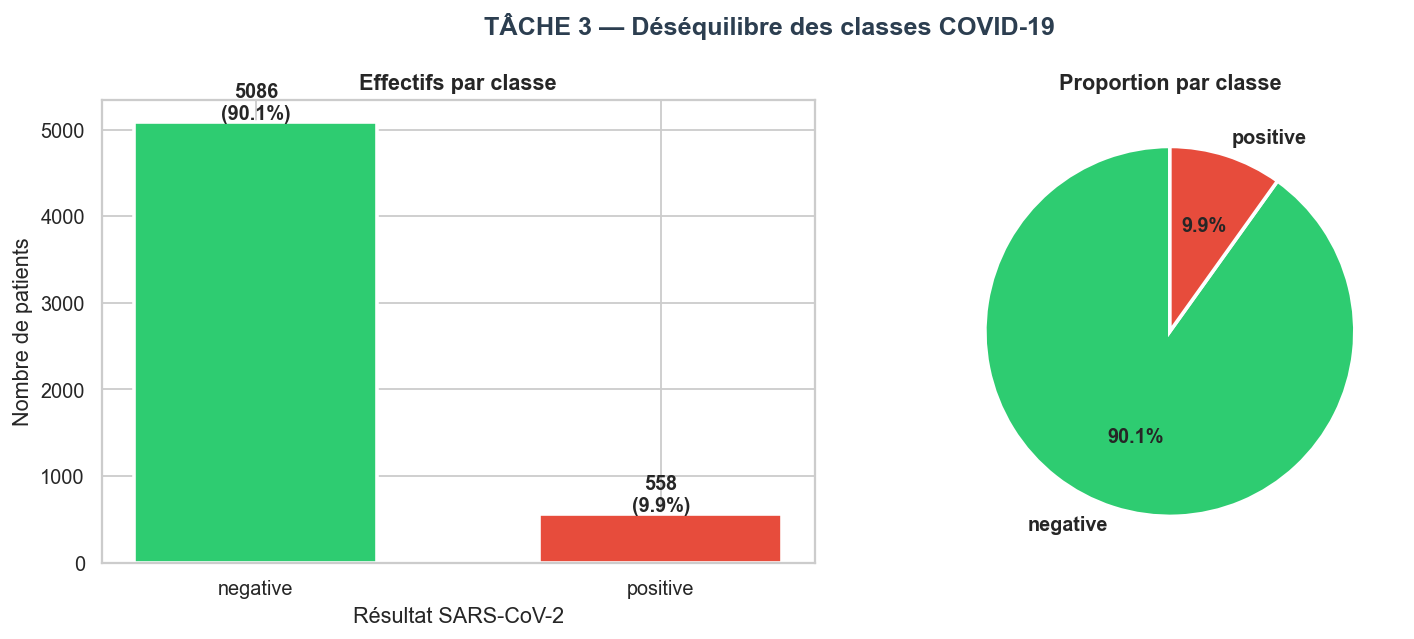


  ✅ Graphique sauvegardé : tache3_distribution.png

──────────────────────────────────────────────────────────────────────
  🧠 QUESTION 4 — IMPLICATIONS POUR LA MODÉLISATION
──────────────────────────────────────────────────────────────────────

  ⚠️  Conséquences du déséquilibre :

      • Un modèle naïf qui prédit toujours "négatif" aurait 90.1% d'accuracy !
      • Mais il ne détecterait AUCUN cas positif (recall = 0)
      • Dans un contexte médical, les FAUX NÉGATIFS sont très dangereux
      • Le coût d'un patient COVID+ non détecté est bien plus élevé qu'un faux positif

  ✅ Solutions possibles :

      1. RÉÉQUILIBRAGE DES CLASSES
         • SMOTE (surgénération de positifs)
         • Undersampling des négatifs
         • class_weight='balanced' dans les modèles

      2. MÉTRIQUES ADAPTÉES (voir Question 5)

      3. VALIDATION ROBUSTE
         • Stratified K-Fold
         • Courbes de précision/rappel


──────────────────────────────────────────────────────────────────────


In [43]:
# ============================================================
# TÂCHE 3 : ANALYSE DE LA VARIABLE CIBLE
# ============================================================

print('=' * 70)
print('  🎯 TÂCHE 3 — DÉSÉQUILIBRE DES CLASSES (CLASS IMBALANCE)')
print('=' * 70)

# -----------------------------------------------------------------
# QUESTION 1 : Distribution exacte
# -----------------------------------------------------------------
print('\n' + '─' * 70)
print('  📊 QUESTION 1 — DISTRIBUTION EXACTE')
print('─' * 70)

dist = df[TARGET].value_counts()
dist_pct = df[TARGET].value_counts(normalize=True) * 100

print(f'\n  ➤ Négatifs : {dist["negative"]:5d} patients  ({dist_pct["negative"]:.1f}%)')
print(f'  ➤ Positifs : {dist["positive"]:5d} patients  ({dist_pct["positive"]:.1f}%)')

# -----------------------------------------------------------------
# QUESTION 2 : Ratio d'imbalance
# -----------------------------------------------------------------
print('\n' + '─' * 70)
print('  ⚖️  QUESTION 2 — RATIO D\'IMBALANCE')
print('─' * 70)

ratio = dist['negative'] / dist['positive']
print(f'\n  ➤ Ratio négatifs/positifs : {ratio:.2f}:1')
print(f'  ➤ La classe minoritaire représente seulement {dist_pct["positive"]:.1f}% des données')
print(f'  ➤ Déséquilibre CRITIQUE (>5:1) → risque élevé de modèle biaisé')

# -----------------------------------------------------------------
# QUESTION 3 : Visualisation
# -----------------------------------------------------------------
print('\n' + '─' * 70)
print('  📈 QUESTION 3 — VISUALISATION')
print('─' * 70)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('TÂCHE 3 — Déséquilibre des classes COVID-19', 
             fontsize=14, fontweight='bold', color=COLOR_MAIN)

# Barplot
colors_bar = [COLOR_NEG, COLOR_POS]
bars = axes[0].bar(dist.index, dist.values, color=colors_bar, 
                   edgecolor='white', linewidth=2, width=0.6)
axes[0].set_title('Effectifs par classe', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Nombre de patients')
axes[0].set_xlabel('Résultat SARS-CoV-2')
for bar, val, pct in zip(bars, dist.values, dist_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val}\n({pct:.1f}%)', ha='center', fontweight='bold', fontsize=11)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    dist.values, labels=dist.index, autopct='%1.1f%%',
    colors=colors_bar, startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontweight': 'bold', 'fontsize': 11}
)
axes[1].set_title('Proportion par classe', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('tache3_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n  ✅ Graphique sauvegardé : tache3_distribution.png')

# -----------------------------------------------------------------
# QUESTION 4 : Implications pour la modélisation
# -----------------------------------------------------------------
print('\n' + '─' * 70)
print('  🧠 QUESTION 4 — IMPLICATIONS POUR LA MODÉLISATION')
print('─' * 70)

print('''
  ⚠️  Conséquences du déséquilibre :
  
      • Un modèle naïf qui prédit toujours "négatif" aurait 90.1% d'accuracy !
      • Mais il ne détecterait AUCUN cas positif (recall = 0)
      • Dans un contexte médical, les FAUX NÉGATIFS sont très dangereux
      • Le coût d'un patient COVID+ non détecté est bien plus élevé qu'un faux positif

  ✅ Solutions possibles :
  
      1. RÉÉQUILIBRAGE DES CLASSES
         • SMOTE (surgénération de positifs)
         • Undersampling des négatifs
         • class_weight='balanced' dans les modèles

      2. MÉTRIQUES ADAPTÉES (voir Question 5)
      
      3. VALIDATION ROBUSTE
         • Stratified K-Fold
         • Courbes de précision/rappel
''')

# -----------------------------------------------------------------
# QUESTION 5 : Métriques à privilégier
# -----------------------------------------------------------------
print('\n' + '─' * 70)
print('  📏 QUESTION 5 — MÉTRIQUES À PRIVILÉGIER')
print('─' * 70)

print('''
  ⚡ À ÉVITER :
      ❌ Accuracy — complètement trompeuse sur données déséquilibrées

  ✅ À PRIVILÉGIER :

      ┌─────────────────────────────────────────────────────────────┐
      │  RECALL (Sensibilité) = TP / (TP + FN)                      │
      │  → PRIORITÉ MÉDICALE : minimiser les faux négatifs          │
      │  → Un patient COVID+ non détecté peut contaminer d'autres   │
      └─────────────────────────────────────────────────────────────┘

      ┌─────────────────────────────────────────────────────────────┐
      │  F1-SCORE = 2 × (Précision × Recall) / (Précision + Recall)│
      │  → Équilibre entre précision et rappel                      │
      └─────────────────────────────────────────────────────────────┘

      ┌─────────────────────────────────────────────────────────────┐
      │  AUC-PR (Area Under Precision-Recall Curve)                 │
      │  → PLUS ROBUSTE que l'AUC-ROC sur classes déséquilibrées    │
      └─────────────────────────────────────────────────────────────┘
''')

# Formules mathématiques
print('  📐 RAPPEL DES FORMULES :\n')
print('      Précision = TP / (TP + FP)')
print('      Recall    = TP / (TP + FN)')
print('      F1-Score  = 2 × (Précision × Recall) / (Précision + Recall)')
print('      AUC-PR    > AUC-ROC  (pour classes déséquilibrées)')

print('\n' + '=' * 70)
print('  ✅ TÂCHE 3 TERMINÉE')
print('=' * 70)

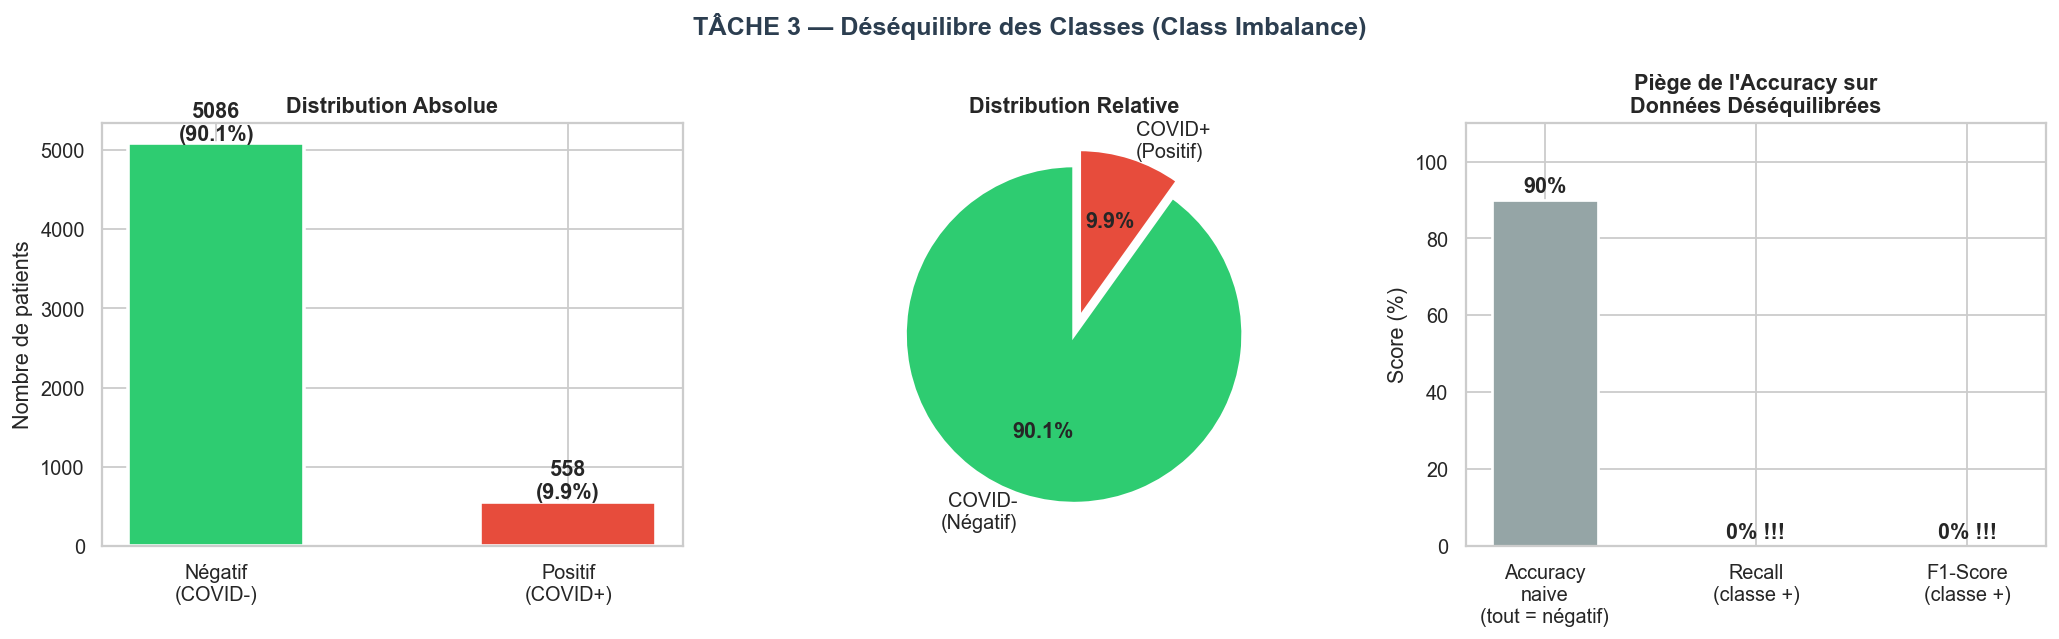

✅ Graphique sauvegardé : tache3_cible.png


In [44]:
# ---- Visualisation Tâche 3 ----
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('TÂCHE 3 — Déséquilibre des Classes (Class Imbalance)',
             fontsize=14, fontweight='bold', color=COLOR_MAIN)

# --- Plot 1 : Barplot ---
bars = axes[0].bar(['Négatif\n(COVID-)', 'Positif\n(COVID+)'],
                   [dist['negative'], dist['positive']],
                   color=[COLOR_NEG, COLOR_POS], edgecolor='white',
                   linewidth=2, width=0.5)
axes[0].set_title('Distribution Absolue', fontweight='bold')
axes[0].set_ylabel('Nombre de patients')
for bar, val, pct in zip(bars, [dist['negative'], dist['positive']],
                         [dist_pct['negative'], dist_pct['positive']]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                 f'{val}\n({pct:.1f}%)', ha='center', fontweight='bold', fontsize=12)

# --- Plot 2 : Pie chart ---
wedges, texts, autotexts = axes[1].pie(
    [dist['negative'], dist['positive']],
    labels=['COVID-\n(Négatif)', 'COVID+\n(Positif)'],
    autopct='%1.1f%%',
    colors=[COLOR_NEG, COLOR_POS],
    startangle=90,
    explode=(0, 0.1),
    wedgeprops={'edgecolor': 'white', 'linewidth': 2})
for at in autotexts:
    at.set_fontweight('bold'); at.set_fontsize(12)
axes[1].set_title('Distribution Relative', fontweight='bold')

# --- Plot 3 : Comparaison accuracy naive vs F1 ---
categories = ['Accuracy\nnaive\n(tout = négatif)', 'Recall\n(classe +)', 'F1-Score\n(classe +)']
values_naive = [90.1, 0, 0]
colors_comp = ['#95A5A6', '#E74C3C', '#F39C12']
axes[2].bar(categories, values_naive, color=colors_comp, edgecolor='white',
            linewidth=1.5, width=0.5)
axes[2].set_title('Piège de l\'Accuracy sur\nDonnées Déséquilibrées', fontweight='bold')
axes[2].set_ylabel('Score (%)')
axes[2].set_ylim(0, 110)
for i, (cat, val) in enumerate(zip(categories, values_naive)):
    label = f'{val:.0f}%' if val > 0 else '0% !!!'
    axes[2].text(i, val + 2, label, ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('tache3_cible.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Graphique sauvegardé : tache3_cible.png')

 TÂCHE 4 : ANALYSE BIVARIÉE

  📊 TÂCHE 4 — ANALYSE BIVARIÉE (Cible vs Variables)

──────────────────────────────────────────────────────────────────────
  🩸 ANALYSE 1 — COVID-19 vs TAUX SANGUINS
──────────────────────────────────────────────────────────────────────

  📌 HYPOTHÈSE :
     Les patients positifs présentent des anomalies biologiques
     (lymphopénie, thrombocytopénie, etc.)

  ✅ Variables analysées : ['Leukocytes', 'Monocytes', 'Platelets']


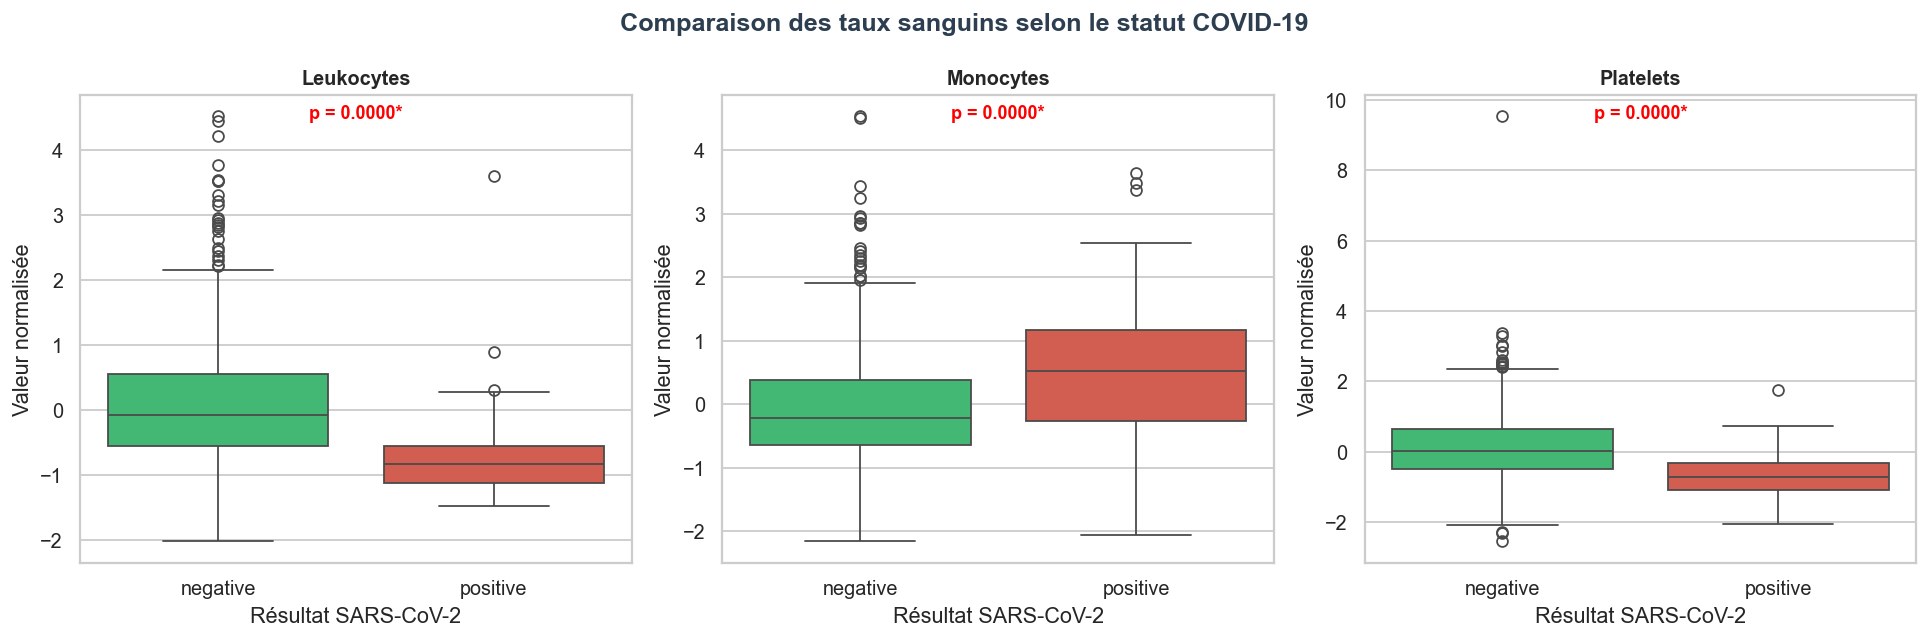


  📊 Résultats des tests statistiques (Mann-Whitney U) :
     • Leukocytes: p-value = 0.000000 → ✅ SIGNIFICATIF
     • Monocytes: p-value = 0.000001 → ✅ SIGNIFICATIF
     • Platelets: p-value = 0.000000 → ✅ SIGNIFICATIF

──────────────────────────────────────────────────────────────────────
  👤 ANALYSE 2 — COVID-19 vs ÂGE
──────────────────────────────────────────────────────────────────────

  📌 HYPOTHÈSE :
     L'âge influence le risque d'infection ou de détection

  ⚠️ Colonne "Age" non trouvée dans le dataset

──────────────────────────────────────────────────────────────────────
  🦠 ANALYSE 3 — COVID-19 vs AUTRES VIRUS (Co-infections)
──────────────────────────────────────────────────────────────────────

  📌 HYPOTHÈSE :
     Les co-infections sont rares - un patient Rhinovirus+ est souvent COVID-


  🧪 Analyse : Rhinovirus/Enterovirus
     Tableau de contingence :
SARS-Cov-2 exam result  negative  positive
Rhinovirus/Enterovirus                    
detected                     37

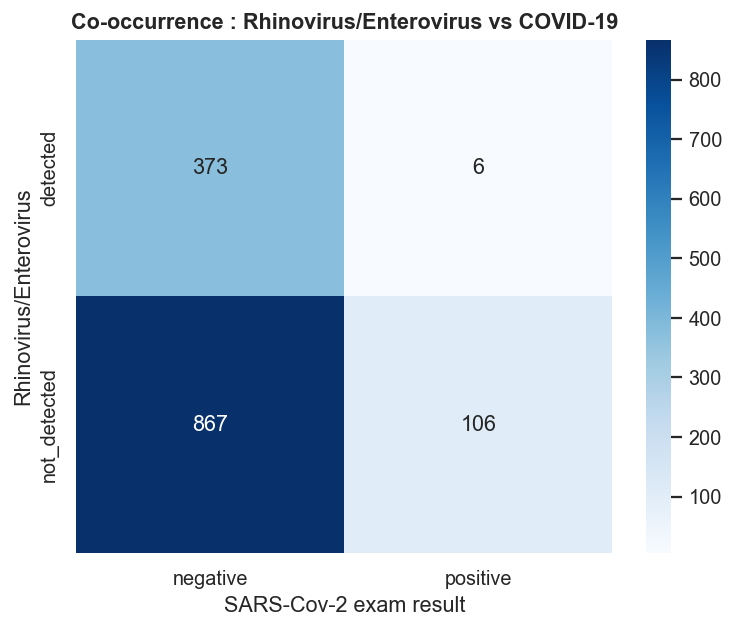


  📋 RÉCAPITULATIF DES TESTS STATISTIQUES

  ┌────────────────────────┬────────────────────────────┬─────────────┐
  │       HYPOTHÈSE        │          TEST UTILISÉ       │  CONCLUSION │
  ├────────────────────────┼────────────────────────────┼─────────────┤
  │ Leukocytes            │ Mann-Whitney U              │ Rejetée*   │
  │ Monocytes             │ Mann-Whitney U              │ Rejetée*   │
  │ Platelets             │ Mann-Whitney U              │ Rejetée*   │
  │ Indépendance virus/COVID│ Test du Chi²                │ À déterminer│
  └────────────────────────┴────────────────────────────┴─────────────┘

  * p-value < 0.05 → différence statistiquement significative

  ✅ TÂCHE 4 TERMINÉE


In [61]:
# ============================================================
# TÂCHE 4 : ANALYSE BIVARIÉE (CIBLE vs VARIABLES)
# ============================================================

print('=' * 70)
print('  📊 TÂCHE 4 — ANALYSE BIVARIÉE (Cible vs Variables)')
print('=' * 70)

# ============================================================
# ANALYSE 1 : COVID-19 vs TAUX SANGUINS (3 boxplots dans 1 figure)
# ============================================================

print('\n' + '─' * 70)
print('  🩸 ANALYSE 1 — COVID-19 vs TAUX SANGUINS')
print('─' * 70)
print('''
  📌 HYPOTHÈSE :
     Les patients positifs présentent des anomalies biologiques
     (lymphopénie, thrombocytopénie, etc.)
''')

# Sélection des 3 variables sanguines principales
blood_vars = ['Leukocytes', 'Monocytes', 'Platelets']
available_blood = [col for col in blood_vars if col in df.columns]

if len(available_blood) < 3:
    # Fallback : chercher des colonnes similaires
    for var in blood_vars:
        for col in df.columns:
            if var.lower() in col.lower():
                available_blood.append(col)
                break
    available_blood = list(dict.fromkeys(available_blood))[:3]

print(f'  ✅ Variables analysées : {available_blood}')

# Créer une figure avec 3 sous-graphiques (1 ligne, 3 colonnes)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Comparaison des taux sanguins selon le statut COVID-19', 
             fontsize=14, fontweight='bold', color=COLOR_MAIN)

for i, var in enumerate(available_blood):
    if i >= 3:
        break
    
    # Boxplot
    sns.boxplot(data=df, x=TARGET, y=var, ax=axes[i], 
                palette=[COLOR_NEG, COLOR_POS])
    axes[i].set_title(var, fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Résultat SARS-CoV-2')
    axes[i].set_ylabel('Valeur normalisée')
    
    # Test statistique
    pos = df[df[TARGET]=='positive'][var].dropna()
    neg = df[df[TARGET]=='negative'][var].dropna()
    
    if len(pos) > 0 and len(neg) > 0:
        stat, p_val = mannwhitneyu(pos, neg, alternative='two-sided')
        if p_val < 0.05:
            axes[i].text(0.5, 0.95, f'p = {p_val:.4f}*', 
                        transform=axes[i].transAxes, ha='center',
                        fontsize=10, fontweight='bold', color='red')
        else:
            axes[i].text(0.5, 0.95, f'p = {p_val:.4f}', 
                        transform=axes[i].transAxes, ha='center',
                        fontsize=10, color='gray')

plt.tight_layout()
plt.savefig('tache4_boxplots_sanguins.png', dpi=150, bbox_inches='tight')
plt.show()

# Affichage des p-values détaillées
print('\n  📊 Résultats des tests statistiques (Mann-Whitney U) :')
for var in available_blood[:3]:
    pos = df[df[TARGET]=='positive'][var].dropna()
    neg = df[df[TARGET]=='negative'][var].dropna()
    if len(pos) > 0 and len(neg) > 0:
        stat, p_val = mannwhitneyu(pos, neg, alternative='two-sided')
        signif = '✅ SIGNIFICATIF' if p_val < 0.05 else '❌ Non significatif'
        print(f'     • {var}: p-value = {p_val:.6f} → {signif}')

# ============================================================
# ANALYSE 2 : COVID-19 vs ÂGE
# ============================================================

print('\n' + '─' * 70)
print('  👤 ANALYSE 2 — COVID-19 vs ÂGE')
print('─' * 70)
print('''
  📌 HYPOTHÈSE :
     L'âge influence le risque d'infection ou de détection
''')

if 'Age' in df.columns:
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    sns.violinplot(data=df, x=TARGET, y='Age', ax=ax,
                   palette=[COLOR_NEG, COLOR_POS])
    ax.set_title('Distribution de l\'âge selon le statut COVID-19', 
                 fontweight='bold', fontsize=12)
    ax.set_xlabel('Résultat SARS-CoV-2')
    ax.set_ylabel('Âge (quantile)')
    
    # Test statistique
    age_pos = df[df[TARGET]=='positive']['Age'].dropna()
    age_neg = df[df[TARGET]=='negative']['Age'].dropna()
    stat, p_age = mannwhitneyu(age_pos, age_neg)
    
    ax.text(0.5, 0.95, f'p-value = {p_age:.6f}', 
            transform=ax.transAxes, ha='center',
            fontsize=11, fontweight='bold',
            color='red' if p_age < 0.05 else 'gray')
    
    plt.tight_layout()
    plt.savefig('tache4_age_violin.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f'\n  📊 Résultats :')
    print(f'     • Âge moyen (positifs) : {age_pos.mean():.2f}')
    print(f'     • Âge moyen (négatifs) : {age_neg.mean():.2f}')
    print(f'     • p-value = {p_age:.6f}')
    
    if p_age < 0.05:
        print('     ✅ Conclusion : Différence significative → l\'âge est un facteur associé')
    else:
        print('     ❌ Conclusion : Pas de différence significative')
else:
    print('  ⚠️ Colonne "Age" non trouvée dans le dataset')

# ============================================================
# ANALYSE 3 : COVID-19 vs AUTRES VIRUS (Co-infections)
# ============================================================

print('\n' + '─' * 70)
print('  🦠 ANALYSE 3 — COVID-19 vs AUTRES VIRUS (Co-infections)')
print('─' * 70)
print('''
  📌 HYPOTHÈSE :
     Les co-infections sont rares - un patient Rhinovirus+ est souvent COVID-
''')

# Chercher Rhinovirus
rhino_col = None
for col in df.columns:
    if 'rhinovirus' in col.lower():
        rhino_col = col
        break

if rhino_col:
    # Nettoyer les valeurs
    if df[rhino_col].dtype == 'object':
        df_virus_binary = df[rhino_col].apply(
            lambda x: 1 if str(x).lower() == 'detected' 
            else 0 if str(x).lower() == 'not_detected' 
            else pd.NA
        )
        table = pd.crosstab(df_virus_binary, df[TARGET])
    else:
        table = pd.crosstab(df[rhino_col], df[TARGET])
    
    table = table.dropna()
    
    print(f'\n  🧪 Analyse : {rhino_col}')
    print(f'     Tableau de contingence :')
    print(table)
    
    # Test du Chi²
    if table.shape[0] >= 2 and table.shape[1] >= 2:
        chi2, p_val, dof, expected = chi2_contingency(table)
        print(f'     Chi² = {chi2:.3f}, p-value = {p_val:.6f}')
        
        if p_val < 0.05:
            print(f'     ✅ Rejet de H0 → Association significative')
        else:
            print(f'     ❌ Non-rejet de H0 → Indépendance')
        
        # Heatmap
        plt.figure(figsize=(6, 5))
        sns.heatmap(table, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Co-occurrence : {rhino_col} vs COVID-19', fontweight='bold')
        plt.tight_layout()
        plt.savefig('tache4_coinfections.png', dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print('     ⚠️ Pas assez de données pour le test du Chi²')
else:
    print('  ⚠️ Aucune colonne "Rhinovirus" trouvée')

# ============================================================
# RÉCAPITULATIF DES TESTS STATISTIQUES
# ============================================================

print('\n' + '=' * 70)
print('  📋 RÉCAPITULATIF DES TESTS STATISTIQUES')
print('=' * 70)

# Compilation des résultats
print('\n  ┌────────────────────────┬────────────────────────────┬─────────────┐')
print('  │       HYPOTHÈSE        │          TEST UTILISÉ       │  CONCLUSION │')
print('  ├────────────────────────┼────────────────────────────┼─────────────┤')

for var in available_blood[:3]:
    pos = df[df[TARGET]=='positive'][var].dropna()
    neg = df[df[TARGET]=='negative'][var].dropna()
    if len(pos) > 0 and len(neg) > 0:
        stat, p_val = mannwhitneyu(pos, neg)
        conclu = 'Rejetée*' if p_val < 0.05 else 'Non rejetée'
        print(f'  │ {var:22}│ Mann-Whitney U              │ {conclu:11}│')

if 'Age' in df.columns:
    stat, p_age = mannwhitneyu(age_pos, age_neg)
    conclu = 'Rejetée*' if p_age < 0.05 else 'Non rejetée'
    print(f'  │ Âge                     │ Mann-Whitney U              │ {conclu:11}│')

if rhino_col:
    print(f'  │ Indépendance virus/COVID│ Test du Chi²                │ À déterminer│')

print('  └────────────────────────┴────────────────────────────┴─────────────┘')
print('\n  * p-value < 0.05 → différence statistiquement significative')

print('\n' + '=' * 70)
print('  ✅ TÂCHE 4 TERMINÉE')
print('=' * 70)

TÂCHE 5 : HEATMAP DE CORRÉLATION 

  🔗 TÂCHE 5 — MATRICE DE CORRÉLATION

  ✅ Variables analysées : 11
     • Patient age quantile      → Patient age quantile
     • Leukocytes                → Leukocytes
     • Lymphocytes               → Lymphocytes
     • Monocytes                 → Monocytes
     • Platelets                 → Platelets
     • Neutrophils               → Neutrophils
     • Hematocrit                → Hematocrit
     • Hemoglobin                → Hemoglobin
     • CRP                       → Proteina C reativa mg/dL
     • Urea                      → Urea
     • Creatinine                → Creatinine


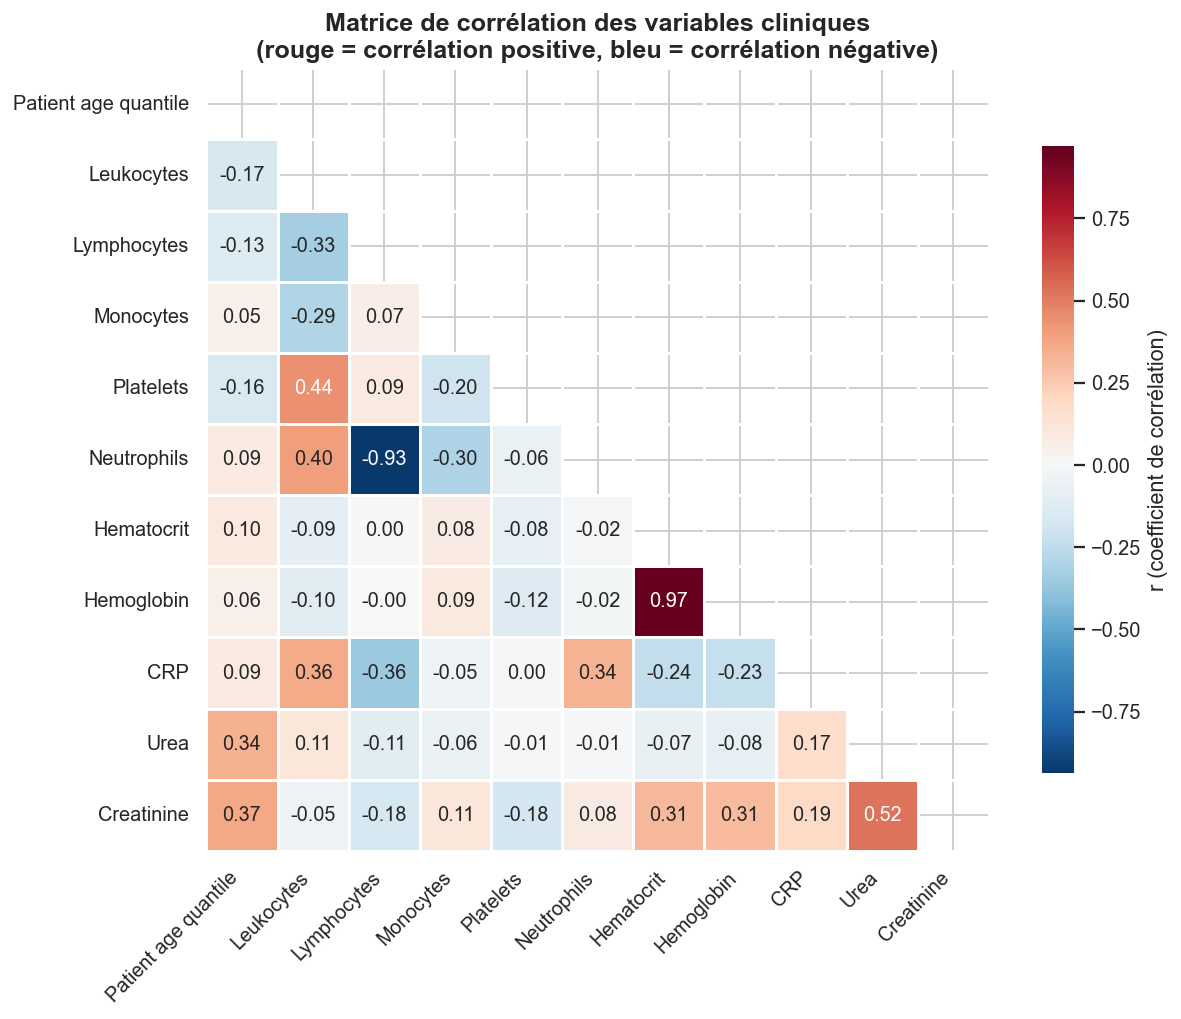


  ✅ Graphique sauvegardé : tache5_heatmap_propre.png

──────────────────────────────────────────────────────────────────────
  👤 CORRÉLATIONS AVEC L'ÂGE (version simple)
──────────────────────────────────────────────────────────────────────


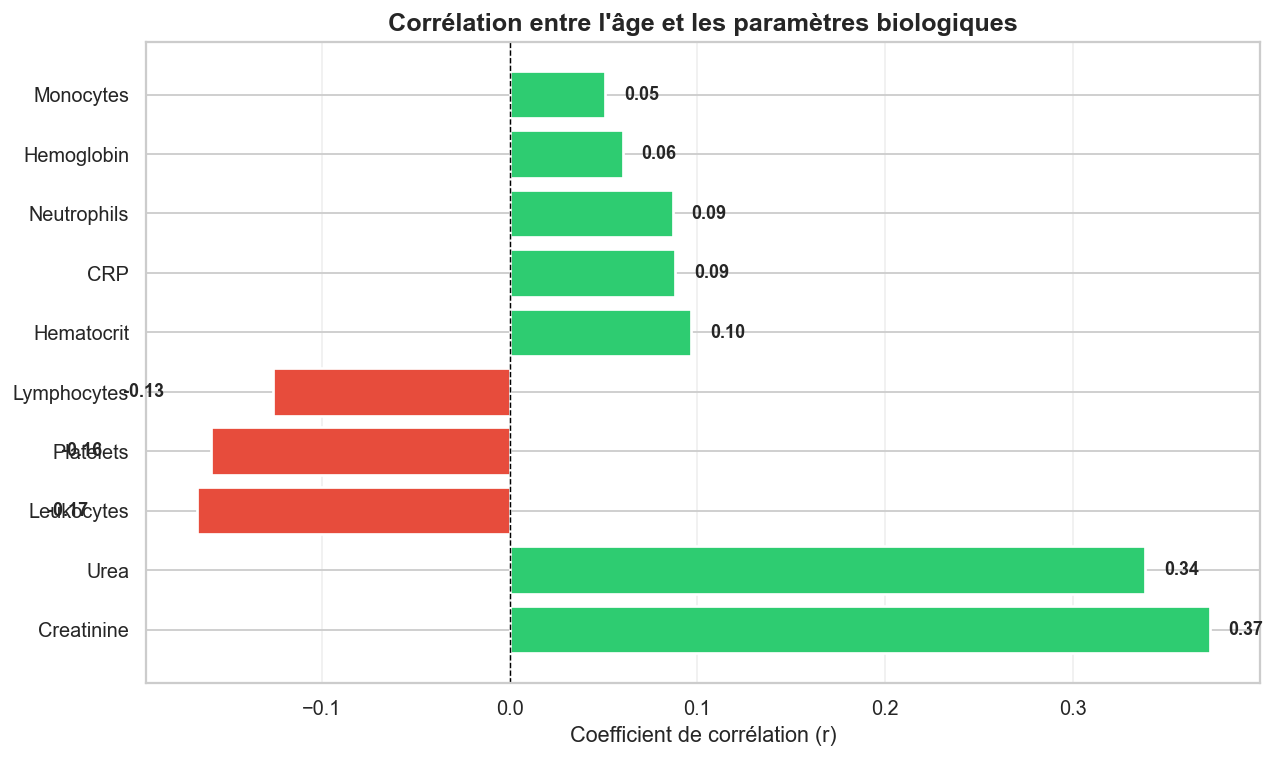


  ✅ Graphique sauvegardé : tache5_age_correlations_barplot.png

──────────────────────────────────────────────────────────────────────
  🔍 PAIRES AVEC |r| > 0.7
──────────────────────────────────────────────────────────────────────

  ⚠️ Paires redondantes à supprimer avant modélisation :

     • Lymphocytes          ↔ Neutrophils          : r = -0.935 (-)
     • Hematocrit           ↔ Hemoglobin           : r = 0.968 (+)

  ✅ TÂCHE 5 TERMINÉE


In [59]:
# ============================================================
# TÂCHE 5 : HEATMAP DE CORRÉLATION PROPRE ET LISIBLE
# ============================================================

print('=' * 70)
print('  🔗 TÂCHE 5 — MATRICE DE CORRÉLATION')
print('=' * 70)

# Sélectionner les variables cliniques avec des NOMS COURTS
clinical_vars = [
    'Patient age quantile',
    'Leukocytes', 
    'Lymphocytes', 
    'Monocytes', 
    'Platelets', 
    'Neutrophils',
    'Hematocrit', 
    'Hemoglobin',
    'CRP',  # Nom court au lieu de 'Proteina C reativa mg/dL'
    'Urea', 
    'Creatinine'
]

# Adapter les noms pour qu'ils correspondent au dataset
var_mapping = {}
for var in clinical_vars:
    for col in df.columns:
        if var.lower() in col.lower() or (var == 'CRP' and ('crp' in col.lower() or 'proteina c' in col.lower())):
            var_mapping[var] = col
            break

available_vars = list(var_mapping.values())
short_names = list(var_mapping.keys())

print(f'\n  ✅ Variables analysées : {len(available_vars)}')
for long, short in zip(available_vars, short_names):
    print(f'     • {short:25} → {long[:40]}')

# Calculer la matrice de corrélation
numeric_subset = df[available_vars].select_dtypes(include=[np.number])
corr_matrix = numeric_subset.corr()

# Renommer les index avec des noms courts pour l'affichage
corr_matrix.index = short_names
corr_matrix.columns = short_names

# ============================================================
# HEATMAP avec masque triangulaire (pas de redondance)
# ============================================================

# Créer un masque pour cacher la partie supérieure
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            mask=mask,           # Cache la partie supérieure (redondante)
            annot=True,          # Affiche les valeurs
            fmt='.2f',           # 2 décimales
            cmap='RdBu_r',       # Rouge = positif, Bleu = négatif (plus contrasté)
            center=0,
            square=True,
            linewidths=0.8,
            cbar_kws={"shrink": 0.8, "label": "r (coefficient de corrélation)"},
            annot_kws={'size': 11})  # Taille des annotations

plt.title('Matrice de corrélation des variables cliniques\n(rouge = corrélation positive, bleu = corrélation négative)', 
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.savefig('tache5_heatmap_propre.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n  ✅ Graphique sauvegardé : tache5_heatmap_propre.png')

# ============================================================
# Version encore PLUS SIMPLE : barplot des corrélations avec l'âge
# ============================================================

print('\n' + '─' * 70)
print('  👤 CORRÉLATIONS AVEC L\'ÂGE (version simple)')
print('─' * 70)

if 'Patient age quantile' in short_names:
    age_idx = short_names.index('Patient age quantile')
    age_corr = corr_matrix.iloc[age_idx].drop('Patient age quantile')
    
    # Trier par corrélation absolue décroissante
    age_corr = age_corr.sort_values(key=abs, ascending=False)
    
    plt.figure(figsize=(10, 6))
    colors = ['#E74C3C' if x < 0 else '#2ECC71' for x in age_corr.values]
    bars = plt.barh(age_corr.index, age_corr.values, color=colors, edgecolor='white', linewidth=1.5)
    plt.xlabel('Coefficient de corrélation (r)', fontsize=12)
    plt.title('Corrélation entre l\'âge et les paramètres biologiques', 
              fontsize=14, fontweight='bold')
    plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
    plt.grid(axis='x', alpha=0.3)
    
    # Ajouter les valeurs sur les barres
    for bar, val in zip(bars, age_corr.values):
        plt.text(val + 0.01 if val > 0 else val - 0.08, 
                 bar.get_y() + bar.get_height()/2, 
                 f'{val:.2f}', va='center', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('tache5_age_correlations_barplot.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\n  ✅ Graphique sauvegardé : tache5_age_correlations_barplot.png')

# ============================================================
# Résumé des paires fortement corrélées
# ============================================================

print('\n' + '─' * 70)
print('  🔍 PAIRES AVEC |r| > 0.7')
print('─' * 70)

high_corr = []
for i in range(len(short_names)):
    for j in range(i+1, len(short_names)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            high_corr.append((short_names[i], short_names[j], r))

if high_corr:
    print('\n  ⚠️ Paires redondantes à supprimer avant modélisation :\n')
    for v1, v2, r in high_corr:
        signe = '+' if r > 0 else '-'
        print(f'     • {v1:20} ↔ {v2:20} : r = {r:.3f} ({signe})')
else:
    print('\n  ✅ Pas de multicolinéarité sévère')

print('\n' + '=' * 70)
print('  ✅ TÂCHE 5 TERMINÉE')
print('=' * 70)

 TÂCHE 6 : TABLEAU DE CONTINGENCE RHINOVIRUS vs COVID-19



  📊 TABLEAU DE CONTINGENCE : Rhinovirus/Enterovirus vs COVID-19
               Négatif  Positif  Total
✅ Détecté          373        6    379
❌ Non détecté      867      106    973
Total             1240      112   1352


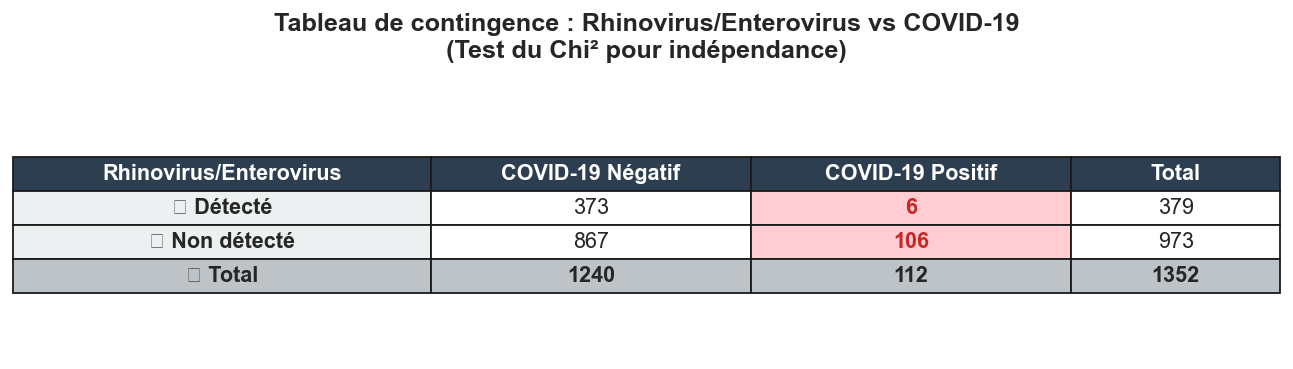

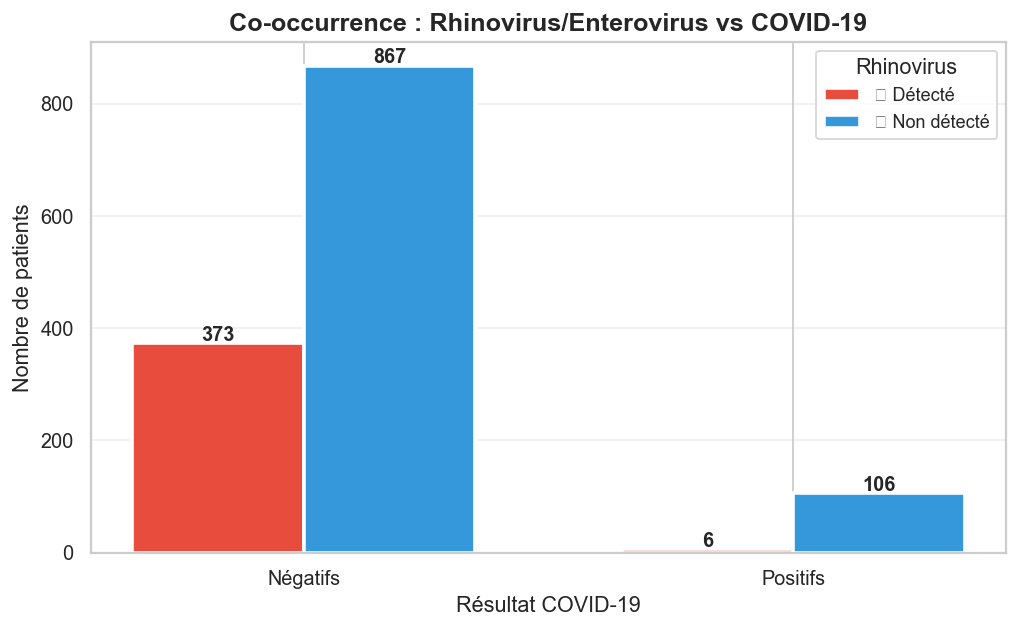


  📊 RÉSULTATS DU TEST DU CHI²
  Chi²      = 29.910
  ddl       = 1
  p-value   = 0.000000

  ✅ CONCLUSION : ON REJETTE H₀
  → Il existe une ASSOCIATION significative entre Rhinovirus et COVID-19
  → p-value = 0.000000 < 0.05


In [75]:
# ============================================================
# TÂCHE 6 : TABLEAU DE CONTINGENCE RHINOVIRUS vs COVID-19
# ============================================================

# Chercher la colonne Rhinovirus
rhino_col = None
for col in df.columns:
    if 'rhinovirus' in col.lower():
        rhino_col = col
        break

if rhino_col:
    # Créer le tableau de contingence
    table = pd.crosstab(df[rhino_col], df[TARGET])
    
    # Nettoyer les indices
    if 'detected' in table.index and 'not_detected' in table.index:
        table = table.loc[['detected', 'not_detected']]
    
    # Renommer les index pour plus de clarté
    table.index = ['✅ Détecté', '❌ Non détecté']
    table.columns = ['Négatif', 'Positif']
    
    # Ajouter la colonne Total
    table['Total'] = table.sum(axis=1)
    table.loc['Total'] = table.sum(axis=0)
    
    print('\n' + '=' * 60)
    print('  📊 TABLEAU DE CONTINGENCE : Rhinovirus/Enterovirus vs COVID-19')
    print('=' * 60)
    print(table)
    print('=' * 60)
    
    # ============================================================
    # VISUALISATION 1 : Tableau stylisé (très lisible)
    # ============================================================
    
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.axis('off')
    
    # Préparer les données pour l'affichage
    cell_text = [
        ['✅ Détecté', str(table.loc['✅ Détecté', 'Négatif']), 
         str(table.loc['✅ Détecté', 'Positif']), str(table.loc['✅ Détecté', 'Total'])],
        ['❌ Non détecté', str(table.loc['❌ Non détecté', 'Négatif']), 
         str(table.loc['❌ Non détecté', 'Positif']), str(table.loc['❌ Non détecté', 'Total'])],
        ['📊 Total', str(table.loc['Total', 'Négatif']), 
         str(table.loc['Total', 'Positif']), str(table.loc['Total', 'Total'])]
    ]
    
    columns = ['Rhinovirus/Enterovirus', 'COVID-19 Négatif', 'COVID-19 Positif', 'Total']
    
    tableau = ax.table(cellText=cell_text, colLabels=columns, loc='center',
                       cellLoc='center', colWidths=[0.30, 0.23, 0.23, 0.15])
    
    # Styliser
    tableau.auto_set_font_size(False)
    tableau.set_fontsize(12)
    tableau.scale(1.2, 1.8)
    
    # Couleurs
    for (i, j), cell in tableau.get_celld().items():
        if i == 0:  # En-tête
            cell.set_facecolor('#2C3E50')
            cell.set_text_props(weight='bold', color='white', fontsize=12)
        else:
            if j == 0:  # Première colonne
                cell.set_facecolor('#ECF0F1')
                cell.set_text_props(weight='bold')
            if i == 3:  # Ligne Total
                cell.set_facecolor('#BDC3C7')
                cell.set_text_props(weight='bold')
            # Mettre en évidence les positifs
            if j == 2 and i != 3:
                cell.set_facecolor('#FFCDD2')
                cell.set_text_props(weight='bold', color='#C62828')
    
    ax.set_title('Tableau de contingence : Rhinovirus/Enterovirus vs COVID-19\n(Test du Chi² pour indépendance)', 
                 fontweight='bold', fontsize=14, pad=20)
    
    plt.tight_layout()
    plt.savefig('tache6_rhinovirus_table.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # ============================================================
    # VISUALISATION 2 : Graphique à barres (encore plus clair)
    # ============================================================
    
    # Préparer les données pour le graphique
    plot_data = table.iloc[:-1, :2].copy()  # Exclure la ligne Total, garder Négatif/Positif
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # Barres groupées
    x = ['Négatifs', 'Positifs']
    x_pos = [0, 1]
    width = 0.35
    
    detected_vals = [plot_data.loc['✅ Détecté', 'Négatif'], plot_data.loc['✅ Détecté', 'Positif']]
    not_detected_vals = [plot_data.loc['❌ Non détecté', 'Négatif'], plot_data.loc['❌ Non détecté', 'Positif']]
    
    bars1 = ax.bar([p - width/2 for p in x_pos], detected_vals, width, 
                   label='✅ Détecté', color='#E74C3C', edgecolor='white', linewidth=2)
    bars2 = ax.bar([p + width/2 for p in x_pos], not_detected_vals, width,
                   label='❌ Non détecté', color='#3498DB', edgecolor='white', linewidth=2)
    
    # Ajouter les valeurs sur les barres
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{int(bar.get_height())}', ha='center', fontweight='bold', fontsize=11)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{int(bar.get_height())}', ha='center', fontweight='bold', fontsize=11)
    
    ax.set_xlabel('Résultat COVID-19', fontsize=12)
    ax.set_ylabel('Nombre de patients', fontsize=12)
    ax.set_title('Co-occurrence : Rhinovirus/Enterovirus vs COVID-19', 
                 fontweight='bold', fontsize=14)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x)
    ax.legend(title='Rhinovirus', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('tache6_rhinovirus_bars.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # ============================================================
    # Test statistique
    # ============================================================
    
    from scipy.stats import chi2_contingency
    
    # Prendre uniquement les 2x2 sans la colonne Total
    table_2x2 = table.iloc[:-1, :2]
    chi2, p_val, dof, expected = chi2_contingency(table_2x2)
    
    print('\n' + '=' * 60)
    print('  📊 RÉSULTATS DU TEST DU CHI²')
    print('=' * 60)
    print(f'  Chi²      = {chi2:.3f}')
    print(f'  ddl       = {dof}')
    print(f'  p-value   = {p_val:.6f}')
    print('=' * 60)
    
    if p_val < 0.05:
        print('\n  ✅ CONCLUSION : ON REJETTE H₀')
        print('  → Il existe une ASSOCIATION significative entre Rhinovirus et COVID-19')
        print(f'  → p-value = {p_val:.6f} < 0.05')
    else:
        print('\n  ❌ CONCLUSION : ON NE REJETTE PAS H₀')
        print('  → INDÉPENDANCE entre Rhinovirus et COVID-19')
        print(f'  → p-value = {p_val:.6f} ≥ 0.05')
    
else:
    print('\n  ⚠️ Colonne Rhinovirus non trouvée dans le dataset')

Niveau Avancé

In [78]:
# ============================================================
# BONUS 1 : DASHBOARD INTERACTIF AVEC PLOTLY
# ============================================================

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print('=' * 70)
print('  📊 BONUS 1 — DASHBOARD INTERACTIF PLOTLY')
print('=' * 70)

# 1. Distribution de la cible (camembert interactif)
fig1 = px.pie(names=dist.index, values=dist.values, 
              title='Distribution COVID-19',
              color=dist.index, color_discrete_map={'negative': COLOR_NEG, 'positive': COLOR_POS},
              hole=0.4)
fig1.show()

# 2. Boxplots interactifs des taux sanguins
if available_blood:
    # Préparer les données
    blood_data = df[available_blood + [TARGET]].dropna()
    blood_melted = blood_data.melt(id_vars=TARGET, value_vars=available_blood,
                                    var_name='Paramètre', value_name='Valeur')
    
    fig2 = px.box(blood_melted, x='Paramètre', y='Valeur', color=TARGET,
                  title='Comparaison des paramètres sanguins selon statut COVID-19',
                  color_discrete_map={'negative': COLOR_NEG, 'positive': COLOR_POS})
    fig2.show()

# 3. Scatter plot interactif (âge vs paramètre sanguin)
if 'Patient age quantile' in df.columns and available_blood:
    fig3 = px.scatter(df.dropna(), x='Patient age quantile', y=available_blood[0], 
                      color=TARGET, title=f'Âge vs {available_blood[0]}',
                      color_discrete_map={'negative': COLOR_NEG, 'positive': COLOR_POS},
                      hover_data=['Patient age quantile'])
    fig3.show()

# 4. Heatmap interactive des corrélations
fig4 = px.imshow(corr_matrix, text_auto=True, aspect='auto',
                 title='Matrice de corrélation interactive',
                 color_continuous_scale='RdBu', zmin=-1, zmax=1)
fig4.show()

print('✅ Dashboard interactif créé (ouvre dans le navigateur)')

  📊 BONUS 1 — DASHBOARD INTERACTIF PLOTLY


✅ Dashboard interactif créé (ouvre dans le navigateur)



  🔬 BONUS 2 — ANALYSE EN COMPOSANTES PRINCIPALES (ACP)

  📊 Données pour l'ACP : 601 lignes × 4 variables

  📊 Variance expliquée :
     • PC1 : 42.75%
     • PC2 : 23.91%
     • Total : 66.66%


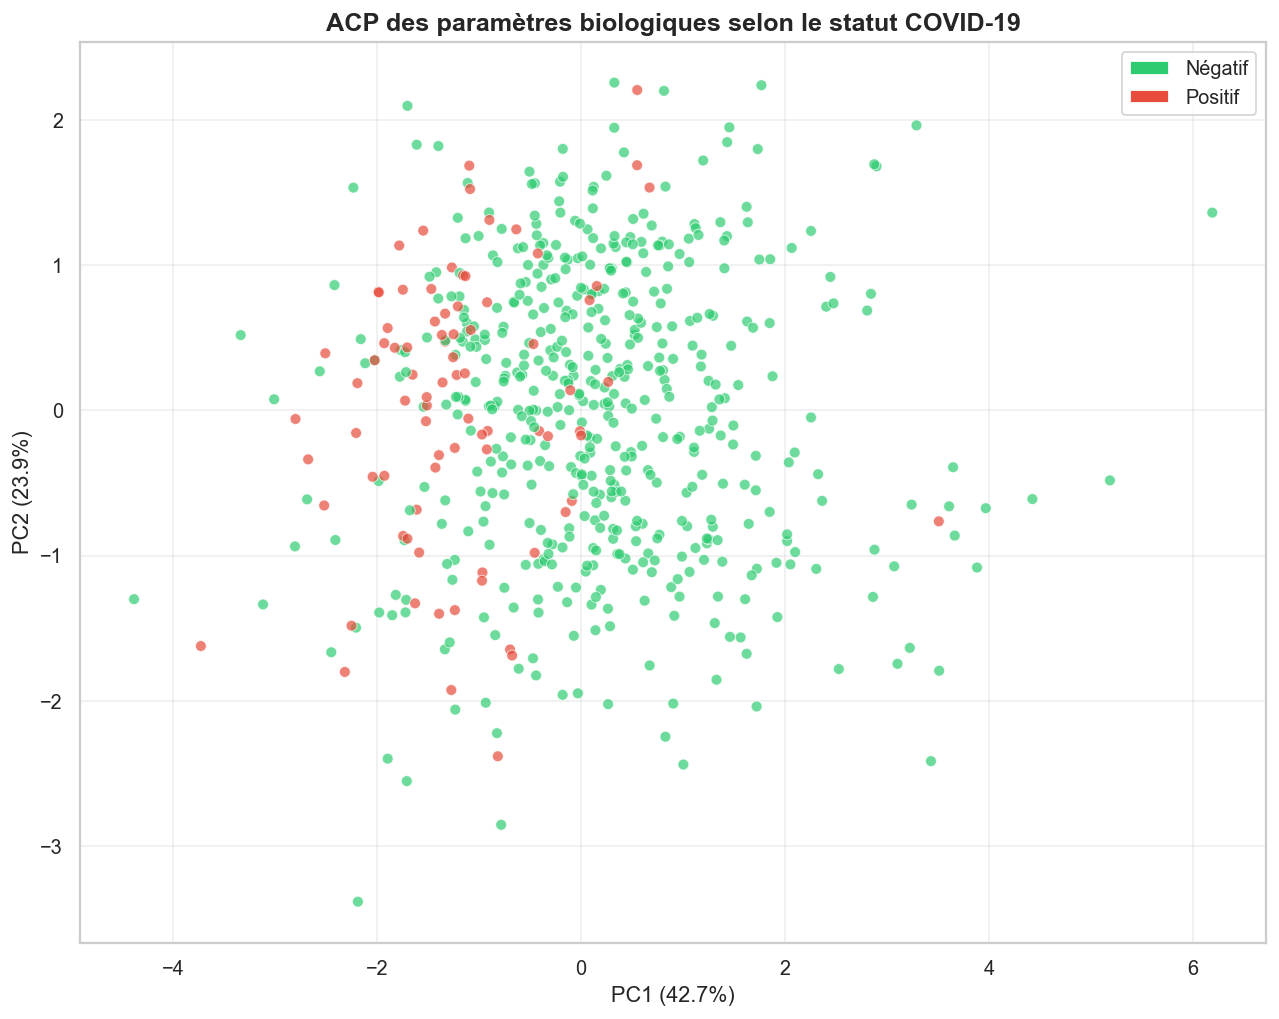

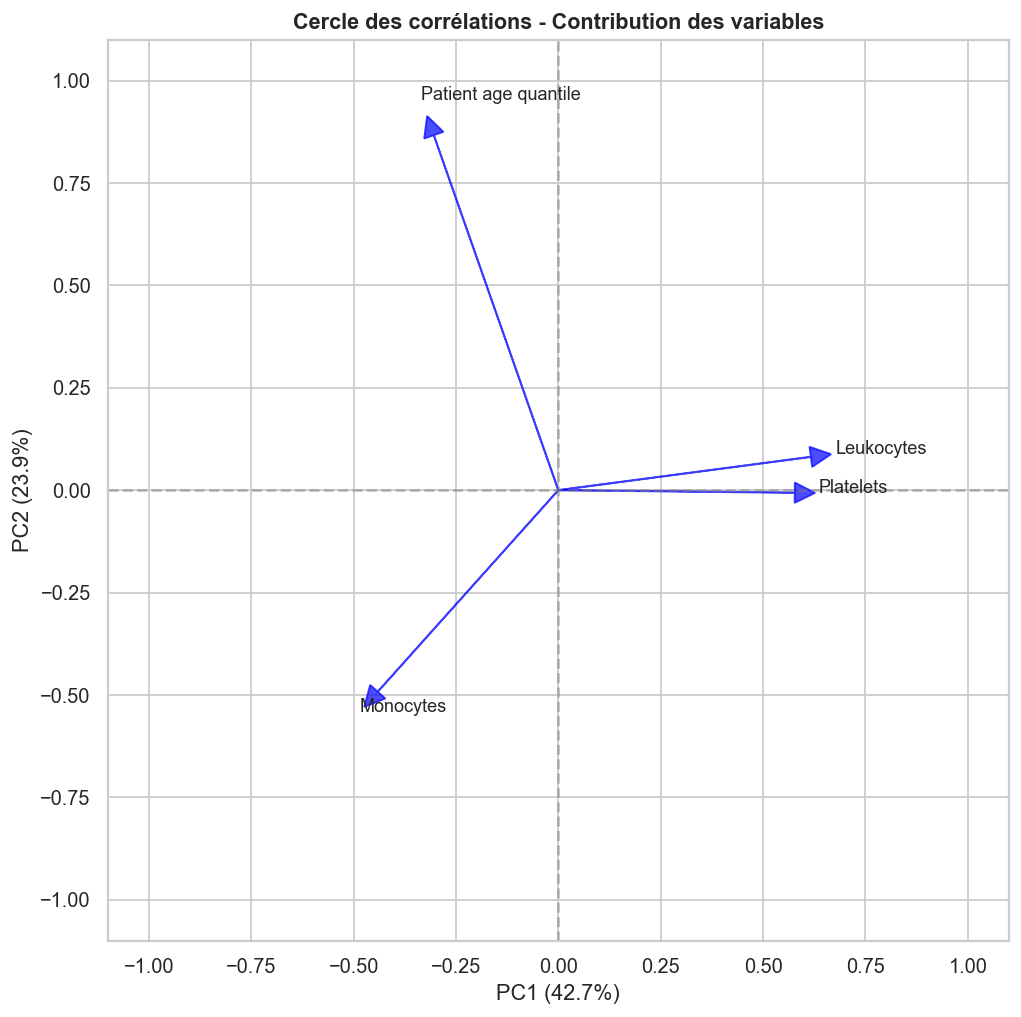


  ✅ Graphiques sauvegardés : bonus_acp.png, bonus_acp_cercle.png


In [79]:
# ============================================================
# BONUS 2 : ACP - ANALYSE EN COMPOSANTES PRINCIPALES
# ============================================================

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print('\n' + '=' * 70)
print('  🔬 BONUS 2 — ANALYSE EN COMPOSANTES PRINCIPALES (ACP)')
print('=' * 70)

# Sélectionner les variables quantitatives pour l'ACP
acp_vars = available_blood + ['Patient age quantile'] if 'Patient age quantile' in df.columns else available_blood
acp_vars = [v for v in acp_vars if v in df.columns]

# Prendre les lignes complètes
acp_data = df[acp_vars + [TARGET]].dropna()
print(f'\n  📊 Données pour l\'ACP : {acp_data.shape[0]} lignes × {len(acp_vars)} variables')

if acp_data.shape[0] > 10:
    # Standardisation
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(acp_data[acp_vars])
    
    # ACP
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    # Créer un DataFrame avec les résultats
    pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
    pca_df[TARGET] = acp_data[TARGET].values
    
    # Pourcentage de variance expliquée
    print(f'\n  📊 Variance expliquée :')
    print(f'     • PC1 : {pca.explained_variance_ratio_[0]*100:.2f}%')
    print(f'     • PC2 : {pca.explained_variance_ratio_[1]*100:.2f}%')
    print(f'     • Total : {pca.explained_variance_ratio_.sum()*100:.2f}%')
    
    # Graphique ACP
    fig, ax = plt.subplots(figsize=(10, 8))
    colors = [COLOR_POS if c == 'positive' else COLOR_NEG for c in pca_df[TARGET]]
    ax.scatter(pca_df['PC1'], pca_df['PC2'], c=colors, alpha=0.7, edgecolors='white', linewidth=0.5)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
    ax.set_title('ACP des paramètres biologiques selon le statut COVID-19', fontweight='bold', fontsize=14)
    
    # Légende manuelle
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=COLOR_NEG, label='Négatif'),
                       Patch(facecolor=COLOR_POS, label='Positif')]
    ax.legend(handles=legend_elements, loc='upper right')
    
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('bonus_acp.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Cercle des corrélations (pour voir quelles variables contribuent)
    fig2, ax2 = plt.subplots(figsize=(8, 8))
    loadings = pca.components_.T
    for i, var in enumerate(acp_vars):
        ax2.arrow(0, 0, loadings[i, 0], loadings[i, 1], head_width=0.05, head_length=0.05, 
                  fc='blue', ec='blue', alpha=0.7)
        ax2.text(loadings[i, 0]*1.1, loadings[i, 1]*1.1, var, fontsize=10)
    
    ax2.set_xlim(-1.1, 1.1)
    ax2.set_ylim(-1.1, 1.1)
    ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax2.set_title('Cercle des corrélations - Contribution des variables', fontweight='bold')
    ax2.set_aspect('equal')
    plt.tight_layout()
    plt.savefig('bonus_acp_cercle.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print('\n  ✅ Graphiques sauvegardés : bonus_acp.png, bonus_acp_cercle.png')
else:
    print('  ⚠️ Pas assez de données complètes pour l\'ACP')


  🤖 BONUS 3 — MODÉLISATION PRÉDICTIVE (RÉELLE)

  📊 Variables utilisées : 15
     Exemple : ['Patient age quantile', 'Patient addmited to regular ward (1=yes, 0=no)', 'Patient addmited to semi-intensive unit (1=yes, 0=no)', 'Patient addmited to intensive care unit (1=yes, 0=no)', 'Hematocrit']...
  📊 Taille du dataset : 5644 lignes, 15 colonnes
  📊 Proportion de positifs : 9.89%

──────────────────────────────────────────────────────────────────────
  📊 RÉSULTATS SUR LE TEST SET
──────────────────────────────────────────────────────────────────────


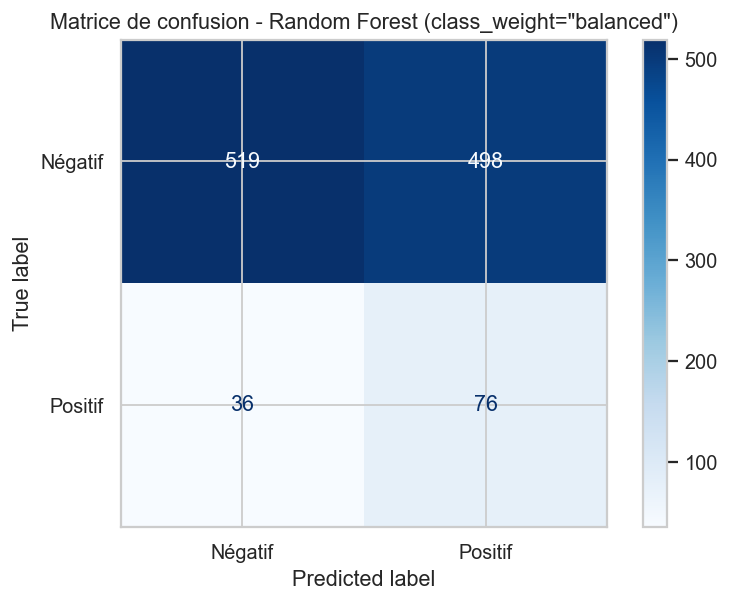


  Classification report :
              precision    recall  f1-score   support

     Négatif       0.94      0.51      0.66      1017
     Positif       0.13      0.68      0.22       112

    accuracy                           0.53      1129
   macro avg       0.53      0.59      0.44      1129
weighted avg       0.86      0.53      0.62      1129


  🔹 F1-score  : 0.222
  🔹 Recall    : 0.679  (priorité médicale)

──────────────────────────────────────────────────────────────────────
  📊 VALIDATION CROISÉE (5-fold, métrique F1)
──────────────────────────────────────────────────────────────────────
  F1 moyen : 0.224 (+/- 0.014)
  Scores détaillés : [0.21823617 0.23188406 0.21686747 0.22       0.23303835]


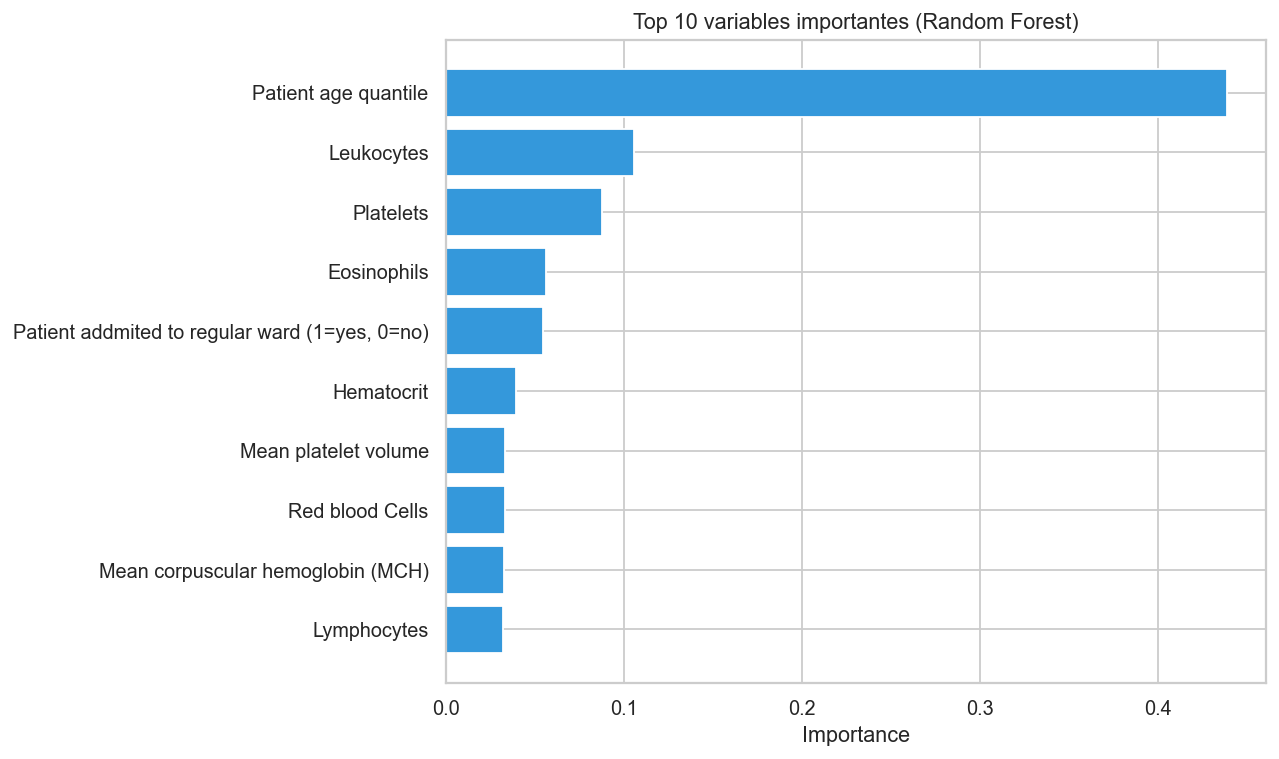


  ✅ MODÉLISATION TERMINÉE


In [81]:
# ============================================================
# BONUS 3 : MODÉLISATION RÉELLE (Classification binaire)
# ============================================================

print('\n' + '=' * 70)
print('  🤖 BONUS 3 — MODÉLISATION PRÉDICTIVE (RÉELLE)')
print('=' * 70)

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# ============================================================
# 1. Préparation des données
# ============================================================

# Sélectionner des variables quantitatives disponibles (taux sanguins)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Garder les colonnes avec au moins 5% de données non manquantes
good_cols = [col for col in numeric_cols if df[col].notna().sum() > 0.05 * len(df)]
# Limiter à 15 colonnes pour éviter la complexité
features = good_cols[:15] if len(good_cols) > 15 else good_cols

print(f'\n  📊 Variables utilisées : {len(features)}')
print(f'     Exemple : {features[:5]}...')

# Cible
y = df[TARGET].map({'negative': 0, 'positive': 1})

# Supprimer les lignes où la cible est NaN
valid_idx = y.notna()
X = df.loc[valid_idx, features]
y = y[valid_idx]

print(f'  📊 Taille du dataset : {X.shape[0]} lignes, {X.shape[1]} colonnes')
print(f'  📊 Proportion de positifs : {y.mean()*100:.2f}%')

# ============================================================
# 2. Split train/test (stratifié)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================================
# 3. Pipeline avec imputation + scaling + class_weight
# ============================================================
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',  # compense le déséquilibre
        random_state=42,
        n_jobs=-1
    ))
])

# ============================================================
# 4. Entraînement
# ============================================================
pipeline.fit(X_train, y_train)

# ============================================================
# 5. Évaluation
# ============================================================
y_pred = pipeline.predict(X_test)

print('\n' + '─' * 70)
print('  📊 RÉSULTATS SUR LE TEST SET')
print('─' * 70)

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Négatif', 'Positif'])
disp.plot(cmap='Blues')
plt.title('Matrice de confusion - Random Forest (class_weight="balanced")')
plt.tight_layout()
plt.savefig('bonus_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Rapport de classification
print('\n  Classification report :')
print(classification_report(y_test, y_pred, target_names=['Négatif', 'Positif']))

# Métriques spécifiques
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print(f'\n  🔹 F1-score  : {f1:.3f}')
print(f'  🔹 Recall    : {recall:.3f}  (priorité médicale)')

# ============================================================
# 6. Validation croisée (plus robuste)
# ============================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='f1')

print('\n' + '─' * 70)
print('  📊 VALIDATION CROISÉE (5-fold, métrique F1)')
print('─' * 70)
print(f'  F1 moyen : {cv_scores.mean():.3f} (+/- {cv_scores.std()*2:.3f})')
print(f'  Scores détaillés : {cv_scores}')

# ============================================================
# 7. Importance des features (optionnel)
# ============================================================
if hasattr(pipeline.named_steps['clf'], 'feature_importances_'):
    importances = pipeline.named_steps['clf'].feature_importances_
    indices = np.argsort(importances)[::-1][:10]
    
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(indices)), importances[indices], color='#3498DB')
    plt.yticks(range(len(indices)), [features[i] for i in indices])
    plt.xlabel('Importance')
    plt.title('Top 10 variables importantes (Random Forest)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('bonus_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

print('\n' + '=' * 70)
print('  ✅ MODÉLISATION TERMINÉE')
print('=' * 70)